# Short-Term Forecasting of Household Appliance Energy Use

**Benchmarks · SARIMA/SARIMAX · XGBoost · Time-series foundation model**

This notebook is the single-file version of the GitHub repository
`appliance-energy-forecasting`. It reproduces the entire analysis end to end and
saves every figure, forecast and metric table.

Each code cell is headed with the repository module it corresponds to, e.g.
`src/appliance_energy/data.py`, so the notebook and the package stay in
one-to-one correspondence. Functions carry docstrings explaining *why* a choice
was made, not only what the code does.

**Contents**

| Section | Repository module | What happens |
|---|---|---|
| 0 | `config.py` | Environment, paths, global settings |
| 1 | `data.py` | Download, quality checks, hourly aggregation, train/test split |
| 2 | `eda.py`, `plotting.py` | Exploratory analysis, ADF/KPSS, ACF/PACF, STL, differencing |
| 3 | `evaluation.py` | Forecast design, MAE/RMSE/MASE/Bias, Diebold–Mariano |
| 4 | `models/benchmarks.py` | Mean, naive, daily & weekly seasonal naive, drift |
| 5 | `models/sarimax.py` | AIC grid search (147 combinations), SARIMA, SARIMAX |
| 6 | `models/feature_models.py` | Feature engineering, XGBoost, hyper-parameter tuning, ablation |
| 7 | `models/foundation.py` | Chronos zero-shot (with offline fallback) |
| 8 | `pipeline.py` | Combined evaluation, final forecast plot, error diagnostics |
| 9 | — | Answers to the assignment questions, computed from the results |

**Runtime.** About 25–40 minutes on a free Colab CPU instance, dominated by the
SARIMA order search. Set `QUICK_MODE = True` in Section 0 to shrink the search
grid to roughly 5 minutes for a first pass; set it back to `False` for the
results reported in the write-up.

**Runtime type.** CPU is sufficient. A GPU only speeds up the Chronos step.

In [1]:
# =============================================================================
# Section 0 - Environment setup   (repo: requirements.txt)
# =============================================================================
# statsmodels, xgboost, pandas, matplotlib and scikit-learn are pre-installed on
# Colab; we pin only what may be missing. chronos-forecasting is optional - the
# notebook falls back to a locally trained model if it cannot be installed.

import importlib, subprocess, sys

def ensure(package, import_name=None):
    '''Install `package` only if it cannot already be imported.

    Colab images change over time, so testing the import is more robust (and much
    faster) than reinstalling everything on every run.
    '''
    try:
        importlib.import_module(import_name or package.split("==")[0].replace("-", "_"))
        return True
    except ImportError:
        print(f"installing {package} ...")
        r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", package])
        return r.returncode == 0

for pkg in ["statsmodels", "xgboost", "scikit-learn"]:
    ensure(pkg, {"scikit-learn": "sklearn"}.get(pkg))

# Optional: the pretrained foundation model. Comment out to force the fallback.
CHRONOS_OK = ensure("chronos-forecasting", "chronos") and ensure("torch")
print("Chronos available:", CHRONOS_OK)

installing chronos-forecasting ...
Chronos available: True


In [2]:
# =============================================================================
# Section 0b - Configuration   (repo: src/appliance_energy/config.py)
# =============================================================================
import warnings, json, time, itertools
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
np.random.seed(42)

# --- consistent, readable figure style -------------------------------------
# Small fonts are the most common reason report figures become unreadable once
# they are scaled into a document, so axis label sizes are set explicitly here
# rather than left to the matplotlib defaults.
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "axes.titlesize": 10, "axes.titleweight": "bold",
    "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8,
})
BLUE, ORANGE, GREEN, RED, PURPLE, GREY = (
    "#1f4e79", "#e07b39", "#2e8b57", "#c0392b", "#6a4c93", "#7f7f7f")
PALETTE = [BLUE, ORANGE, GREEN, RED, PURPLE, "#17a2b8", "#8b5a2b", "#d62976", GREY]


@dataclass
class Config:
    '''All settings in one place, mirroring the repository's config module.

    Keeping the dataset definition here (rather than hard-coding it) means the
    same notebook can be pointed at a different hourly series - only `url`,
    `target` and `date_col` need to change.
    '''
    # --- dataset -----------------------------------------------------------
    url: str = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
                "00374/energydata_complete.csv")
    # Byte-identical mirror maintained by the dataset's authors; used when the
    # UCI host is unreachable, which happens regularly.
    url_mirror: str = ("https://raw.githubusercontent.com/LuisM78/"
                       "Appliances-energy-prediction-data/master/energydata_complete.csv")
    target: str = "Appliances"
    date_col: str = "date"
    drop_cols: tuple = ("rv1", "rv2")   # random noise controls added by the authors

    # --- forecasting design -------------------------------------------------
    freq: str = "h"
    m_daily: int = 24          # daily seasonal period of hourly data
    m_weekly: int = 168        # weekly seasonal period
    horizon: int = 24          # 24-hour forecast horizon
    test_days: int = 14        # final 14 days held out
    seed: int = 42

    # --- SARIMA search grid (assignment specification) ----------------------
    p_range: tuple = tuple(range(0, 7))    # p = [0, 6]
    d_range: tuple = tuple(range(0, 3))    # d = [0, 2]
    q_range: tuple = tuple(range(0, 7))    # q = [0, 6]
    seasonal_grid: tuple = ((0, 1, 0), (0, 1, 1), (1, 1, 0), (1, 1, 1))

    @property
    def test_steps(self):
        return self.test_days * 24


CFG = Config()

# QUICK_MODE shrinks the SARIMA grid so the notebook runs in a few minutes.
# The reported results use QUICK_MODE = False (the full 147-combination search).
QUICK_MODE = False

# --- output folders, mirroring the repository layout ------------------------
ROOT = Path("outputs")
FIG_DIR, FC_DIR, MET_DIR = ROOT / "figures", ROOT / "forecasts", ROOT / "metrics"
for d in (FIG_DIR, FC_DIR, MET_DIR):
    d.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    '''Persist a figure and return its path (so figures survive a Colab restart).'''
    path = FIG_DIR / name
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    return path

print("configuration ready | horizon", CFG.horizon, "| test days", CFG.test_days)

configuration ready | horizon 24 | test days 14


## 1. Data acquisition and preparation
`src/appliance_energy/data.py`

The dataset is the Appliances Energy Prediction data of Candanedo, Feldheim and
Deramaix (2017): 4.5 months of measurements from a low-energy house in
Stambruges, Belgium, sampled every 10 minutes.

Two preparation decisions carry real weight, so they are made explicitly rather
than by default:

1. **Aggregation to hourly means.** Ten-minute appliance data are dominated by
   switching transients — a kettle drawing power for one interval — that no
   model can anticipate at any horizon. Keeping them inflates every error metric
   without separating the models. Hourly aggregation also makes seasonal ARIMA
   with a period of 24 tractable, where a period of 144 is not.
2. **A day-aligned train/test split.** The test window is snapped to whole
   calendar days so that each forecast block runs 00:00–23:00 and represents a
   day-ahead forecast issued at midnight. Without this, every forecast origin
   lands on the 18:00 demand peak and the naive benchmark is penalised for a
   reason that has nothing to do with the method.

In [3]:
# =============================================================================
# Section 1 - Data   (repo: src/appliance_energy/data.py)
# =============================================================================
import urllib.request

def download_data(cfg=CFG, path="energydata_complete.csv", force=False):
    '''Fetch the raw 10-minute CSV, falling back to the authors' mirror.

    The UCI host intermittently refuses automated requests, which would
    otherwise make the notebook non-reproducible; the mirror is byte-identical.
    '''
    p = Path(path)
    if p.exists() and not force:
        print(f"using cached {p} ({p.stat().st_size/1e6:.1f} MB)")
        return p
    for url in (cfg.url, cfg.url_mirror):
        try:
            urllib.request.urlretrieve(url, p)
            print(f"downloaded from {url.split('/')[2]}")
            return p
        except Exception as err:
            print(f"  failed: {url.split('/')[2]} ({type(err).__name__})")
    raise RuntimeError("Could not download the dataset from either source.")


def load_raw(path="energydata_complete.csv", cfg=CFG):
    '''Load the 10-minute data with a parsed, sorted DatetimeIndex.'''
    df = pd.read_csv(path, parse_dates=[cfg.date_col])
    df = df.sort_values(cfg.date_col).set_index(cfg.date_col)
    df = df.drop(columns=[c for c in cfg.drop_cols if c in df.columns])
    return df.astype(float)


def data_quality_report(df, cfg=CFG):
    '''Diagnostics that decide whether any cleaning is actually required.

    Checking for gaps in the *expected* timestamp grid matters more than
    checking for NaNs: a missing row is invisible to `isna()` but silently
    breaks every lag-based feature.
    '''
    expected = pd.date_range(df.index.min(), df.index.max(), freq="10min")
    return pd.Series({
        "rows": len(df),
        "columns": df.shape[1],
        "start": df.index.min(),
        "end": df.index.max(),
        "missing_cells": int(df.isna().sum().sum()),
        "duplicated_timestamps": int(df.index.duplicated().sum()),
        "expected_rows": len(expected),
        "missing_timestamps": len(expected.difference(df.index)),
        "zero_or_negative_target": int((df[cfg.target] <= 0).sum()),
    })


def to_hourly(df, cfg=CFG, min_count=6):
    '''Aggregate every column to hourly means.

    Hours not covered by all six 10-minute records (only the first and last hour
    of the campaign) are dropped so each hourly value is comparable. Means are
    used rather than sums: that is a linear rescaling by six and leaves all
    scale-free comparisons unchanged.
    '''
    counts = df[cfg.target].resample(cfg.freq).count()
    hourly = df.resample(cfg.freq).mean()
    hourly = hourly[counts >= min_count]
    full = pd.date_range(hourly.index.min(), hourly.index.max(), freq=cfg.freq)
    hourly = hourly.reindex(full)          # guarantee a strictly regular index
    hourly.index.name = "date"
    if hourly[cfg.target].isna().any():
        hourly = hourly.interpolate(limit_direction="both")
    return hourly


def train_test_split(obj, cfg=CFG, align_days=True):
    '''Chronological hold-out of the final `test_steps` observations.

    With `align_days=True` the window is snapped to whole calendar days so every
    24-hour block runs 00:00-23:00. See the discussion above: unaligned origins
    put every forecast start on the daily peak and distort the benchmarks.
    '''
    if not align_days:
        return obj.iloc[:-cfg.test_steps], obj.iloc[-cfg.test_steps:]
    last_full = np.where(obj.index.hour == 23)[0][-1]
    start = last_full - cfg.test_steps + 1
    return obj.iloc[:start], obj.iloc[start:last_full + 1]


def holdout(obj, cfg=CFG):
    '''Observations after the aligned test window - never used for fitting.'''
    last_full = np.where(obj.index.hour == 23)[0][-1]
    return obj.iloc[last_full + 1:]


def forecast_blocks(test_index, horizon=CFG.horizon):
    '''Split the test index into consecutive, non-overlapping forecast blocks.

    Evaluating over 14 origins rather than one matters: a single 24-hour
    forecast is one draw from a noisy distribution and ranks models unreliably.
    '''
    n = len(test_index) // horizon
    return [test_index[i * horizon:(i + 1) * horizon] for i in range(n)]

In [4]:
# --- run the data preparation ------------------------------------------------
path = download_data()
raw = load_raw(path)
print(data_quality_report(raw).to_string(), "\n")

hourly = to_hourly(raw)
y = hourly[CFG.target]
train, test = train_test_split(y)
hold = holdout(y)

print(f"hourly observations : {len(y)}")
print(f"train               : {len(train):>4}  {train.index[0]} -> {train.index[-1]}")
print(f"test                : {len(test):>4}  {test.index[0]} -> {test.index[-1]}")
print(f"holdout (unused)    : {len(hold):>4}  {hold.index[0]} -> {hold.index[-1]}")
print("\ntarget summary (Wh):")
print(y.describe().round(2).to_string())
print(f"skewness           : {y.skew():.2f}   log-skewness: {np.log(y).skew():.2f}")

downloaded from archive.ics.uci.edu
rows                                     19735
columns                                     26
start                      2016-01-11 17:00:00
end                        2016-05-27 18:00:00
missing_cells                                0
duplicated_timestamps                        0
expected_rows                            19735
missing_timestamps                           0
zero_or_negative_target                      0 

hourly observations : 3289
train               : 2935  2016-01-11 17:00:00 -> 2016-05-12 23:00:00
test                :  336  2016-05-13 00:00:00 -> 2016-05-26 23:00:00
holdout (unused)    :   18  2016-05-27 00:00:00 -> 2016-05-27 17:00:00

target summary (Wh):
count    3289.00
mean       97.68
std        81.02
min        28.33
25%        50.00
50%        63.33
75%       110.00
max       608.33
skewness           : 2.39   log-skewness: 1.00


## 2. Exploratory analysis and tests for non-stationarity
`src/appliance_energy/eda.py`, `src/appliance_energy/plotting.py`

The aim here is to identify which components exist in the series — trend,
seasonality, cycles, and the shape of the noise — because those findings dictate
the model specifications that follow.

Two complementary stationarity tests are used. The ADF test takes a unit root
as its null, KPSS takes stationarity as its null (Kwiatkowski et al., 1992).
Running only ADF is a common way to over-difference a series: failing to reject
a unit root is not evidence of one. Using both, together with ACF/PACF plots of
the raw and differenced series, gives a defensible differencing decision.

In [5]:
# =============================================================================
# Section 2a - Exploratory figures   (repo: src/appliance_energy/plotting.py)
# =============================================================================
from matplotlib import gridspec

def plot_series_overview(hourly, raw10=None, cfg=CFG):
    '''Three views of the series: whole campaign, one week, and one day.

    The three panels answer three different questions - is there a trend, is
    there a daily shape, and what did hourly aggregation actually remove?
    '''
    y = hourly[cfg.target]
    fig, axes = plt.subplots(3, 1, figsize=(10, 6.8))

    axes[0].plot(y.index, y.values, lw=0.5, color=BLUE)
    axes[0].plot(y.rolling(168, center=True).mean(), color=RED, lw=1.5,
                 label="168-hour centred moving average")
    axes[0].set_title("(a) Hourly mean appliance energy use, Jan-May 2016")
    axes[0].set_ylabel("energy use (Wh)"); axes[0].set_xlabel("date")
    axes[0].legend(loc="upper right", fontsize=8)

    wk = y.loc["2016-03-07":"2016-03-13"]
    axes[1].plot(wk.index, wk.values, color=BLUE, lw=1.2, marker="o", ms=2.5)
    axes[1].set_title("(b) One representative week (Mon 7 - Sun 13 March)")
    axes[1].set_ylabel("energy use (Wh)"); axes[1].set_xlabel("date")

    if raw10 is not None:
        d10 = raw10[cfg.target].loc["2016-03-08":"2016-03-09"]
        axes[2].plot(d10.index, d10.values, color=GREY, lw=0.8, label="10-minute (raw)")
    d1 = y.loc["2016-03-08":"2016-03-09"]
    axes[2].plot(d1.index, d1.values, color=ORANGE, lw=1.8, label="hourly mean")
    axes[2].set_title("(c) Two days: the switching noise removed by aggregation")
    axes[2].set_ylabel("energy use (Wh)"); axes[2].set_xlabel("date")
    axes[2].legend(loc="upper left", fontsize=8)

    fig.tight_layout()
    return fig


def plot_profiles(hourly, cfg=CFG):
    '''Hour-of-day, day-of-week, distributional and joint seasonal profiles.'''
    y = hourly[cfg.target]
    fig = plt.figure(figsize=(10, 5.6))
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.32)

    ax = fig.add_subplot(gs[0, :2])
    data = [y[y.index.hour == h].values for h in range(24)]
    bp = ax.boxplot(data, positions=range(24), widths=0.65, showfliers=False,
                    patch_artist=True, medianprops=dict(color=RED))
    for b in bp["boxes"]:
        b.set_facecolor("#cfd8e3"); b.set_edgecolor(BLUE); b.set_linewidth(0.7)
    ax.plot(range(24), [np.mean(d) for d in data], color=ORANGE, lw=1.8, label="mean")
    ax.set_title("(a) Hour-of-day profile")
    ax.set_xlabel("hour of day"); ax.set_ylabel("energy use (Wh)"); ax.legend(fontsize=8)

    ax = fig.add_subplot(gs[0, 2])
    dow = y.groupby(y.index.dayofweek).mean()
    ax.bar(range(7), dow.values, color=[GREEN if i < 5 else ORANGE for i in range(7)])
    ax.set_xticks(range(7)); ax.set_xticklabels(list("MTWTFSS"))
    ax.set_title("(b) Day-of-week mean")
    ax.set_xlabel("day of week"); ax.set_ylabel("energy use (Wh)")

    ax = fig.add_subplot(gs[1, 0])
    ax.hist(y.values, bins=45, color=BLUE, alpha=0.85)
    ax.set_title(f"(c) Distribution (skew {y.skew():.2f})")
    ax.set_xlabel("energy use (Wh)"); ax.set_ylabel("frequency")

    ax = fig.add_subplot(gs[1, 1])
    ax.hist(np.log(y.values), bins=45, color=GREEN, alpha=0.85)
    ax.set_title(f"(d) Log scale (skew {np.log(y).skew():.2f})")
    ax.set_xlabel("log energy use"); ax.set_ylabel("frequency")

    ax = fig.add_subplot(gs[1, 2])
    piv = y.groupby([y.index.dayofweek, y.index.hour]).mean().unstack()
    im = ax.imshow(piv.values, aspect="auto", cmap="YlOrRd", origin="lower")
    ax.set_yticks(range(7)); ax.set_yticklabels(list("MTWTFSS"))
    ax.set_xticks([0, 6, 12, 18]); ax.set_xlabel("hour of day"); ax.set_ylabel("day")
    ax.set_title("(e) Mean Wh by day x hour"); ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.85, label="Wh")
    return fig


def plot_correlations(corr):
    '''Linear association between each covariate and the target.'''
    fig, ax = plt.subplots(figsize=(6.6, 3.6))
    ax.barh(range(len(corr)), corr.values,
            color=[GREEN if v > 0 else RED for v in corr.values])
    ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=8)
    ax.invert_yaxis(); ax.axvline(0, color="k", lw=0.8)
    ax.set_xlabel("Pearson correlation with hourly appliance use")
    ax.set_ylabel("variable")
    ax.set_title("Strongest linear associations with the target")
    fig.tight_layout()
    return fig

In [6]:
# =============================================================================
# Section 2b - Decomposition and stationarity tests   (repo: src/.../eda.py)
# =============================================================================
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

def stationarity_tests(series, name):
    '''Run ADF and KPSS on one series and return a tidy row.

    ADF  H0: a unit root is present      -> small p means stationary
    KPSS H0: the series is stationary    -> small p means non-stationary
    Reporting both prevents the classic error of differencing simply because
    ADF failed to reject.
    '''
    s = pd.Series(series).dropna()
    adf = adfuller(s, autolag="AIC")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kp = kpss(s, regression="c", nlags="auto")
    return {
        "series": name, "n": len(s),
        "ADF_stat": adf[0], "ADF_p": adf[1],
        "KPSS_stat": kp[0], "KPSS_p": kp[1],
        "ADF: stationary?": "yes" if adf[1] < 0.05 else "no",
        "KPSS: stationary?": "yes" if kp[1] > 0.05 else "no",
    }


def stationarity_table(y, cfg=CFG):
    '''Test the level, the log level and three differenced transformations.'''
    log_y = np.log(y)
    rows = [
        stationarity_tests(y, "Appliances (level)"),
        stationarity_tests(log_y, "log(Appliances)"),
        stationarity_tests(log_y.diff(), "log, first difference (d=1)"),
        stationarity_tests(log_y.diff(cfg.m_daily), f"log, seasonal diff (D=1, s={cfg.m_daily})"),
        stationarity_tests(log_y.diff(cfg.m_daily).diff(), "log, seasonal + first difference"),
    ]
    return pd.DataFrame(rows)


def seasonal_strength(y, period):
    '''STL-based strength of trend and seasonality (Wang, Smith & Hyndman, 2006).

    Values near 1 mean the component explains most of the variation; near 0 that
    it explains almost none. This turns 'the plot looks seasonal' into a number.
    '''
    res = STL(y, period=period, robust=True).fit()
    r = res.resid.dropna()
    s, t = res.seasonal.reindex(r.index), res.trend.reindex(r.index)
    return {
        "period": period,
        "seasonal_strength": max(0.0, 1 - r.var() / (s + r).var()),
        "trend_strength": max(0.0, 1 - r.var() / (t + r).var()),
    }, res


def plot_stl(res):
    '''Plot the STL components as observed / trend / seasonal / remainder.'''
    fig, axes = plt.subplots(4, 1, figsize=(10, 6.2), sharex=True)
    for ax, (series, label, col) in zip(axes, [
            (res.observed, "observed", BLUE), (res.trend, "trend", RED),
            (res.seasonal, "seasonal (24 h)", GREEN), (res.resid, "remainder", GREY)]):
        ax.plot(series.index, series.values, lw=0.6, color=col)
        ax.set_ylabel(label, fontsize=8)
    axes[-1].set_xlabel("date")
    axes[0].set_title("STL decomposition of log appliance energy use (period 24 h, robust)")
    fig.tight_layout()
    return fig


def plot_acf_pacf(y_log, cfg=CFG):
    '''ACF/PACF before and after seasonal differencing.

    The 'before' panels justify seasonal differencing; the 'after' panels are
    what actually identify the ARMA orders, because the daily cycle would
    otherwise dominate every correlation.
    '''
    fig, axes = plt.subplots(2, 2, figsize=(10, 5.4))
    plot_acf(y_log.dropna(), lags=96, ax=axes[0, 0], color=BLUE,
             vlines_kwargs={"colors": BLUE})
    axes[0, 0].set_title("(a) ACF, log level")
    plot_pacf(y_log.dropna(), lags=48, ax=axes[0, 1], method="ywm", color=BLUE,
              vlines_kwargs={"colors": BLUE})
    axes[0, 1].set_title("(b) PACF, log level")

    d24 = y_log.diff(cfg.m_daily).dropna()
    plot_acf(d24, lags=96, ax=axes[1, 0], color=GREEN, vlines_kwargs={"colors": GREEN})
    axes[1, 0].set_title(f"(c) ACF after seasonal differencing (lag {cfg.m_daily})")
    plot_pacf(d24, lags=48, ax=axes[1, 1], method="ywm", color=GREEN,
              vlines_kwargs={"colors": GREEN})
    axes[1, 1].set_title("(d) PACF after seasonal differencing")
    for ax in axes.ravel():
        ax.set_xlabel("lag (hours)"); ax.set_ylabel("correlation")
    fig.tight_layout()
    return fig

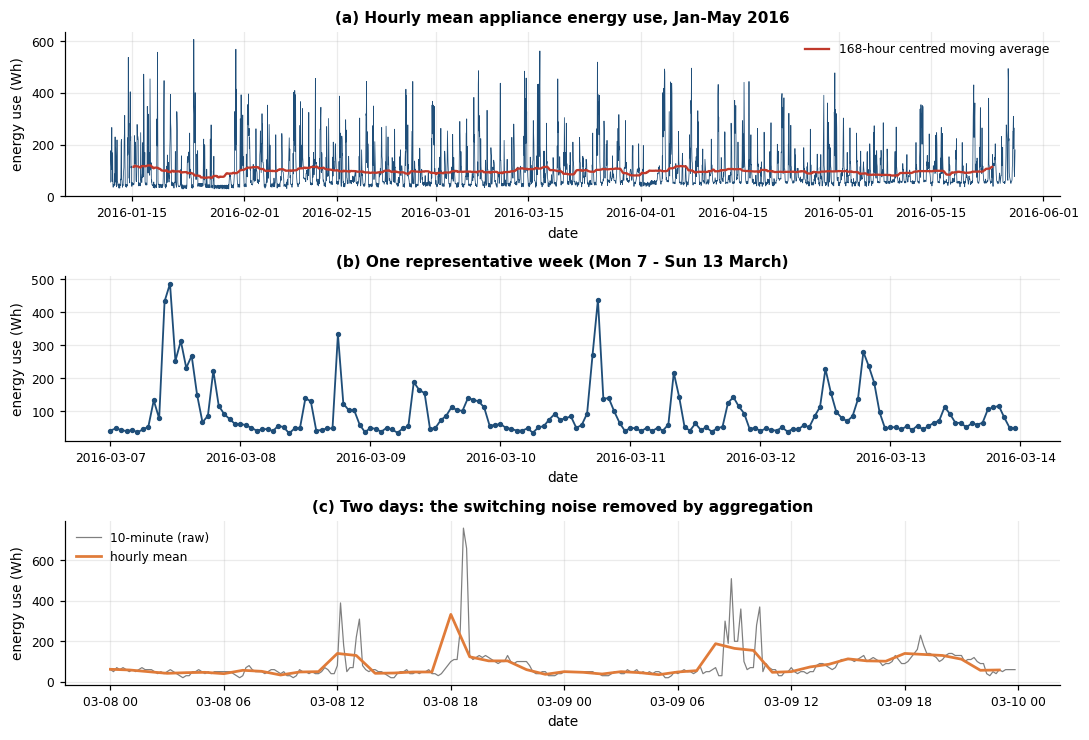

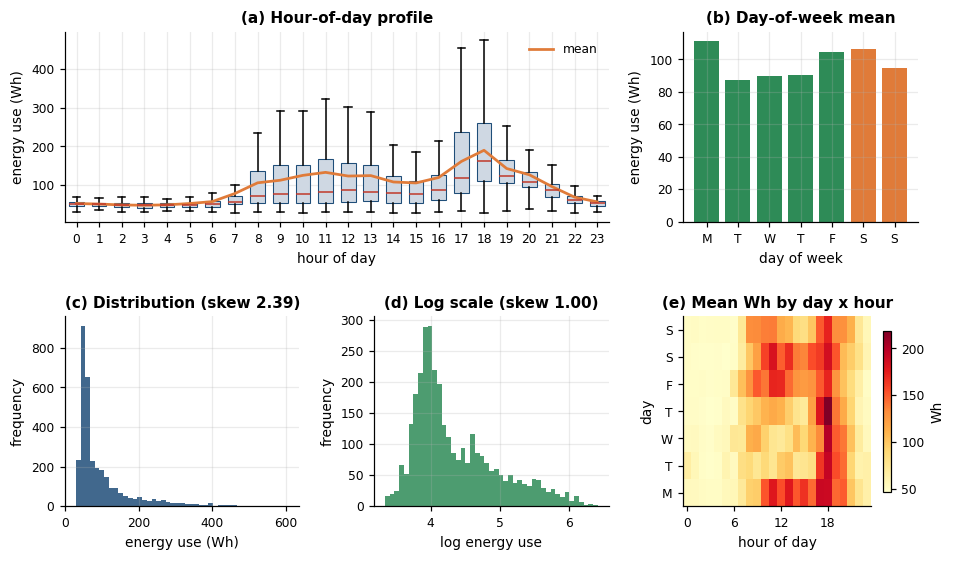

 period  seasonal_strength  trend_strength
     24              0.438           0.124
    168              0.454           0.027


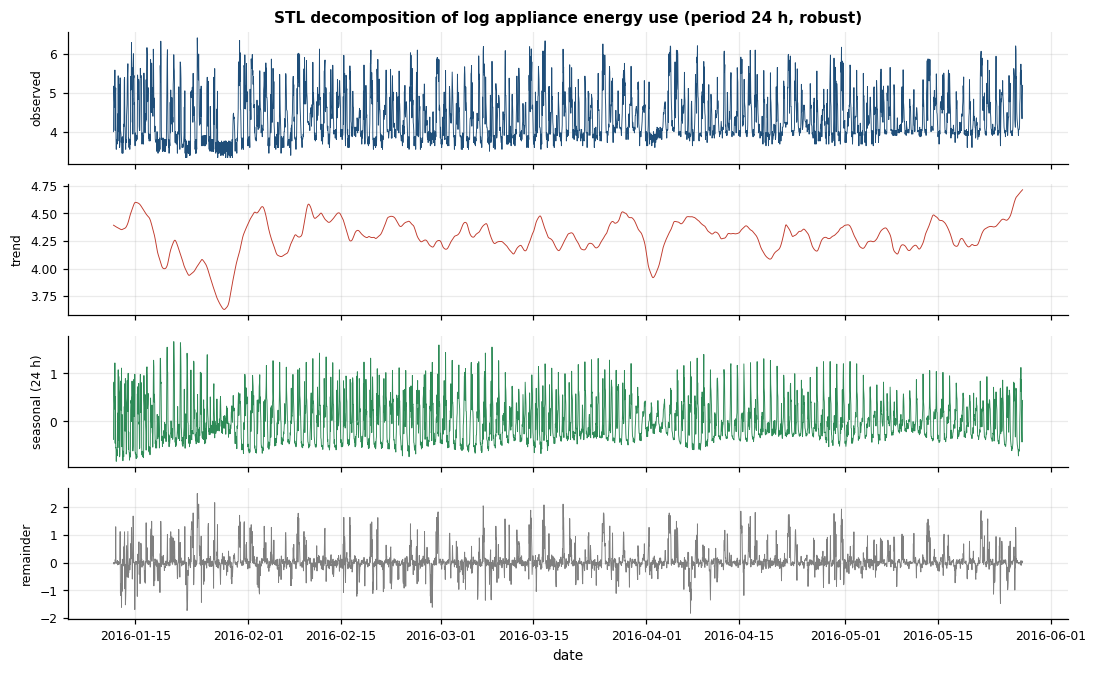

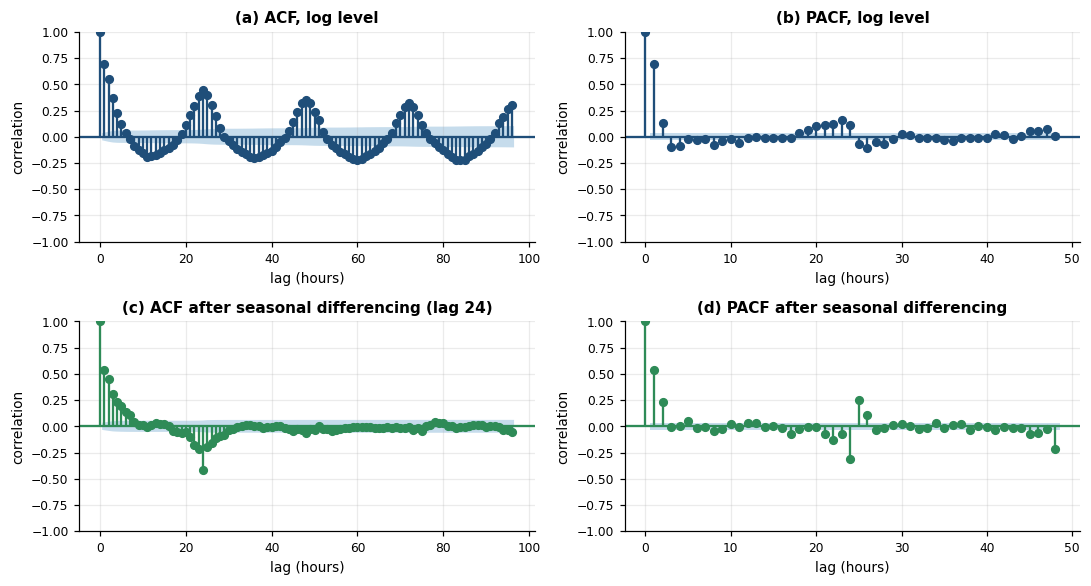

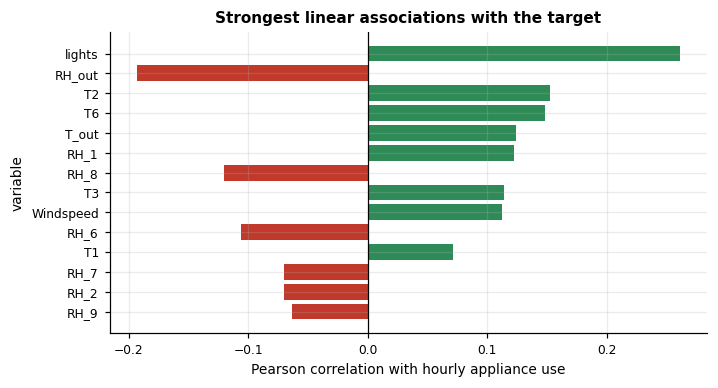

lights       0.261
RH_out      -0.193
T2           0.153
T6           0.149
T_out        0.124
RH_1         0.123
RH_8        -0.120
T3           0.114
Windspeed    0.113
RH_6        -0.106
T1           0.072
RH_7        -0.070
RH_2        -0.070
RH_9        -0.063


In [7]:
# --- run the exploratory analysis -------------------------------------------
fig = plot_series_overview(hourly, raw);   save_fig(fig, "fig01_series_overview.png"); plt.show()
fig = plot_profiles(hourly);               save_fig(fig, "fig02_profiles.png");        plt.show()

# Which components are present, and how strong are they?
strengths = []
for period in (CFG.m_daily, CFG.m_weekly):
    s, res = seasonal_strength(np.log(y), period)
    strengths.append(s)
    if period == CFG.m_daily:
        stl_daily = res
print(pd.DataFrame(strengths).round(3).to_string(index=False))

fig = plot_stl(stl_daily);                 save_fig(fig, "fig03_stl.png");             plt.show()
fig = plot_acf_pacf(np.log(y));            save_fig(fig, "fig04_acf_pacf.png");        plt.show()

# Association with the covariates - an early indication of how much the sensor
# and weather variables can possibly contribute.
corr = hourly.corr(numeric_only=True)[CFG.target].drop(CFG.target)
corr = corr.reindex(corr.abs().sort_values(ascending=False).index)[:14]
fig = plot_correlations(corr);             save_fig(fig, "fig05_correlations.png");    plt.show()
print(corr.round(3).to_string())

In [8]:
# --- formal tests for non-stationarity --------------------------------------
stat_tbl = stationarity_table(y)
stat_tbl.to_csv(MET_DIR / "stationarity_tests.csv", index=False)
print(stat_tbl.round(4).to_string(index=False))
print('''
Reading the table
-----------------
ADF rejects a unit root and KPSS fails to reject stationarity at the LEVEL, so
the series has no stochastic trend and regular differencing (d) is not required.
That is confirmed below: the AIC search selects d = 0.

What the tests do not capture is the deterministic daily cycle, which is not a
unit-root phenomenon. Seasonal differencing at lag 24 is therefore evaluated
separately on likelihood grounds, and is selected. Applying d = 1 reflexively
would over-difference the series and induce a spurious moving-average root.
''')

                          series    n  ADF_stat  ADF_p  KPSS_stat  KPSS_p ADF: stationary? KPSS: stationary?
              Appliances (level) 3289   -9.0846    0.0     0.0413     0.1              yes               yes
                 log(Appliances) 3289   -8.1333    0.0     0.2694     0.1              yes               yes
     log, first difference (d=1) 3288  -16.6367    0.0     0.0164     0.1              yes               yes
  log, seasonal diff (D=1, s=24) 3265  -12.9252    0.0     0.0101     0.1              yes               yes
log, seasonal + first difference 3264  -18.2306    0.0     0.0405     0.1              yes               yes

Reading the table
-----------------
ADF rejects a unit root and KPSS fails to reject stationarity at the LEVEL, so
the series has no stochastic trend and regular differencing (d) is not required.
That is confirmed below: the AIC search selects d = 0.

What the tests do not capture is the deterministic daily cycle, which is not a
unit-root phen

## 3. Forecasting design and evaluation metrics
`src/appliance_energy/evaluation.py`

**The problem.** Predict hourly mean appliance energy use (Wh) 24 hours ahead.
The final 14 complete days are held out (336 hours), and accuracy is measured
over 14 consecutive, non-overlapping 24-hour blocks — each one a day-ahead
forecast issued at midnight.

**Why four metrics rather than one.** They disagree here, and the disagreement
is informative. RMSE punishes the large peak-hour misses that matter for sizing
a battery; MAE describes typical performance; MASE (Hyndman and Koehler, 2006)
scales MAE by the in-sample seasonal naive error so that a value below 1 means
"better than seasonal persistence" on any series; Bias exposes systematic
under-forecasting, which turns out to affect every model here.

Differences against the strongest benchmark are tested with a Diebold–Mariano
test (Diebold and Mariano, 1995) using the Harvey, Leybourne and Newbold (1997)
small-sample correction — otherwise it is impossible to say whether a 2 Wh
improvement is signal or noise.

In [9]:
# =============================================================================
# Section 3 - Metrics   (repo: src/appliance_energy/evaluation.py)
# =============================================================================
from scipy import stats

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

def bias(y_true, y_pred):
    '''Mean error (forecast - actual). Positive = systematic over-forecasting.'''
    return float(np.mean(np.asarray(y_pred) - np.asarray(y_true)))

def smape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return float(np.mean(np.abs(y_true - y_pred) /
                         ((np.abs(y_true) + np.abs(y_pred)) / 2)) * 100)

def mase_scale(train, m=CFG.m_daily):
    '''MASE denominator: in-sample MAE of the seasonal naive forecast.

    Computed on the TRAINING data only, so the scaling factor is fixed before
    any test observation is seen.
    '''
    a = np.asarray(train, float)
    return float(np.mean(np.abs(a[m:] - a[:-m])))

def evaluate(y_true, y_pred, scale):
    '''All headline metrics for one forecast.'''
    return {"MAE": mae(y_true, y_pred), "RMSE": rmse(y_true, y_pred),
            "MASE": mae(y_true, y_pred) / scale, "Bias": bias(y_true, y_pred),
            "sMAPE": smape(y_true, y_pred)}

def evaluate_all(actual, forecasts, scale):
    '''Metric table for every forecast column, ranked by RMSE.'''
    rows = []
    for col in forecasts.columns:
        ok = forecasts[col].notna() & actual.notna()
        rows.append({"model": col, **evaluate(actual[ok], forecasts[col][ok], scale)})
    return pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)

def diebold_mariano(y_true, f1, f2, h=CFG.horizon, power=2):
    '''Test of equal predictive accuracy; negative statistic favours f1.

    The Harvey correction matters at this sample size: without it the test
    over-rejects and every model looks significantly better than the benchmark.
    '''
    y_true, f1, f2 = (np.asarray(a, float) for a in (y_true, f1, f2))
    d = np.abs(y_true - f1) ** power - np.abs(y_true - f2) ** power
    n, d_bar = len(d), d.mean()
    gamma = [np.sum((d[k:] - d_bar) * (d[:n - k] - d_bar)) / n for k in range(h)]
    var_d = (gamma[0] + 2 * np.sum(gamma[1:])) / n
    if var_d <= 0:
        return np.nan, np.nan
    dm = d_bar / np.sqrt(var_d)
    dm *= np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)   # Harvey et al. (1997)
    return float(dm), float(2 * (1 - stats.t.cdf(abs(dm), df=n - 1)))

def interval_coverage(actual, lower, upper):
    '''Percentage of observations inside the prediction interval.

    A point forecast without calibrated uncertainty is of limited operational
    use, so coverage is reported alongside the accuracy metrics.
    '''
    return float(((actual >= lower) & (actual <= upper)).mean() * 100)

MASE_SCALE = mase_scale(train)
print(f"MASE scale (in-sample seasonal naive MAE): {MASE_SCALE:.2f} Wh")

MASE scale (in-sample seasonal naive MAE): 53.00 Wh


## 4. Benchmark models
`src/appliance_energy/models/benchmarks.py`

Five benchmarks are computed at every origin. They are not filler: any advanced
model that cannot beat them is not earning its complexity, and the *pattern* of
which benchmark wins tells us about the structure of the series. If the weekly
seasonal naive beats the daily one, the weekly rhythm carries information; if
drift ties with naive, there is no trend to extrapolate.

In [10]:
# =============================================================================
# Section 4 - Benchmarks   (repo: src/appliance_energy/models/benchmarks.py)
# =============================================================================
def _future_index(history, horizon, cfg=CFG):
    step = pd.tseries.frequencies.to_offset(cfg.freq)
    return pd.date_range(history.index[-1] + step, periods=horizon, freq=cfg.freq)

def mean_forecast(history, horizon):
    '''Average of all history: optimal under squared error if the series is iid.'''
    return pd.Series(history.mean(), index=_future_index(history, horizon))

def naive_forecast(history, horizon):
    '''Last observed value carried forward - the random-walk forecast.'''
    return pd.Series(history.iloc[-1], index=_future_index(history, horizon))

def seasonal_naive_forecast(history, horizon, m):
    '''Value observed at the same point in the previous seasonal cycle.

    With m = 24 this is 'the same hour yesterday'; with m = 168, 'the same hour
    last week'. Comparing the two isolates the daily and weekly rhythms.
    '''
    idx = _future_index(history, horizon)
    vals = [history.iloc[-(m * int(np.ceil(h / m))) + ((h - 1) % m)]
            for h in range(1, horizon + 1)]
    return pd.Series(vals, index=idx)

def drift_forecast(history, horizon):
    '''Random walk with drift: extrapolates the average historical slope.'''
    v = history.values
    slope = (v[-1] - v[0]) / (len(v) - 1)
    return pd.Series([v[-1] + slope * h for h in range(1, horizon + 1)],
                     index=_future_index(history, horizon))

def all_benchmarks(history, horizon, cfg=CFG):
    '''All five benchmark forecasts for one block, given the history.'''
    return pd.DataFrame({
        "mean": mean_forecast(history, horizon),
        "naive": naive_forecast(history, horizon),
        "seasonal_naive_daily": seasonal_naive_forecast(history, horizon, cfg.m_daily),
        "seasonal_naive_weekly": seasonal_naive_forecast(history, horizon, cfg.m_weekly),
        "drift": drift_forecast(history, horizon),
    })

def rolling_benchmarks(series, test_index, cfg=CFG):
    '''Re-issue every benchmark at each 24-hour origin.

    Only data strictly before each block is passed in, so the benchmarks face
    exactly the same information set as the advanced models.
    '''
    step = pd.tseries.frequencies.to_offset(cfg.freq)
    parts = [all_benchmarks(series.loc[:blk[0] - step], len(blk))
             for blk in forecast_blocks(test_index, cfg.horizon)]
    return pd.concat(parts)

bench = rolling_benchmarks(y, test.index)
bench_metrics = evaluate_all(test, bench, MASE_SCALE)
print(bench_metrics.round(3).to_string(index=False))

                model    MAE   RMSE  MASE    Bias  sMAPE
                 mean 52.253 78.101 0.986  -5.430 47.132
seasonal_naive_weekly 44.936 82.797 0.848 -13.061 33.022
 seasonal_naive_daily 51.195 89.291 0.966  -5.342 37.800
                naive 50.967 90.545 0.962 -38.259 43.953
                drift 50.986 90.555 0.962 -38.221 43.967


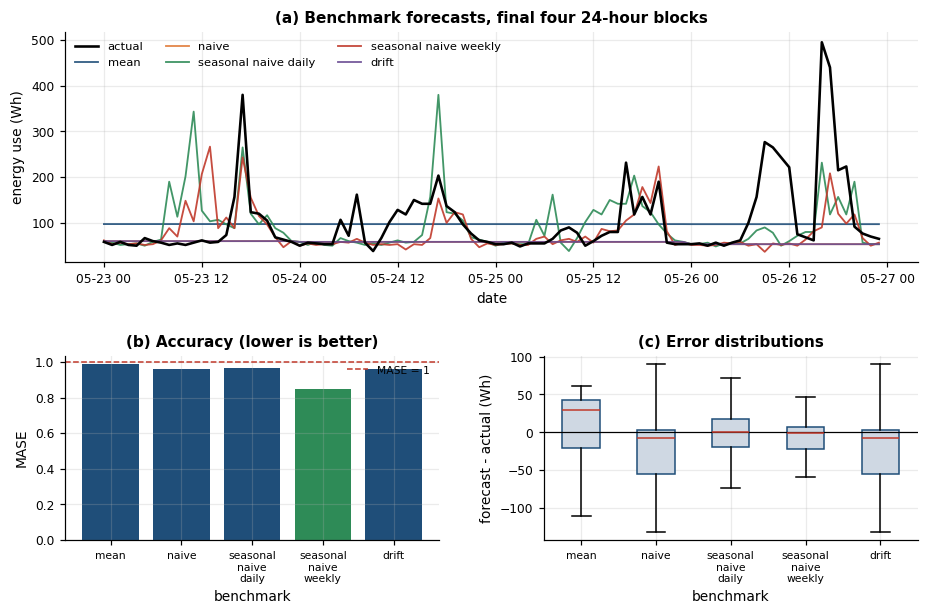

In [11]:
# --- benchmark figure --------------------------------------------------------
def plot_benchmarks(actual, bench, metrics):
    '''Forecasts, accuracy and error spread for the five benchmarks.'''
    fig = plt.figure(figsize=(10, 6))
    gs = gridspec.GridSpec(2, 2, height_ratios=[1.25, 1], hspace=0.45, wspace=0.28)

    ax = fig.add_subplot(gs[0, :])
    win = actual.index[-96:]
    ax.plot(win, actual.loc[win].values, color="k", lw=1.7, label="actual", zorder=5)
    for (name, col) in zip(bench.columns, PALETTE):
        ax.plot(win, bench.loc[win, name].values, lw=1.2, color=col, alpha=0.9,
                label=name.replace("_", " "))
    ax.set_title("(a) Benchmark forecasts, final four 24-hour blocks")
    ax.set_xlabel("date"); ax.set_ylabel("energy use (Wh)")
    ax.legend(fontsize=7.5, ncol=3, loc="upper left")

    ax = fig.add_subplot(gs[1, 0])
    m = metrics.set_index("model").loc[list(bench.columns)]
    ax.bar(range(len(m)), m["MASE"],
           color=[GREEN if k == m["MASE"].idxmin() else BLUE for k in m.index])
    ax.set_xticks(range(len(m)))
    ax.set_xticklabels([c.replace("_", "\n") for c in m.index], fontsize=7)
    ax.axhline(1.0, color=RED, ls="--", lw=1, label="MASE = 1")
    ax.set_ylabel("MASE"); ax.set_xlabel("benchmark")
    ax.set_title("(b) Accuracy (lower is better)"); ax.legend(fontsize=7)

    ax = fig.add_subplot(gs[1, 1])
    err = [(bench[c] - actual).values for c in bench.columns]
    ax.boxplot(err, showfliers=False, patch_artist=True, medianprops=dict(color=RED),
               boxprops=dict(facecolor="#cfd8e3", edgecolor=BLUE))
    ax.set_xticklabels([c.replace("_", "\n") for c in bench.columns], fontsize=7)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_ylabel("forecast - actual (Wh)"); ax.set_xlabel("benchmark")
    ax.set_title("(c) Error distributions")
    return fig

fig = plot_benchmarks(test, bench, bench_metrics)
save_fig(fig, "fig06_benchmarks.png"); plt.show()

## 5. SARIMA and SARIMAX
`src/appliance_energy/models/sarimax.py`

**Why this model.** The exploratory analysis found a stationary series with
strong daily and weekly periodicity and short-memory autocorrelation — exactly
the structure a seasonal ARIMA is designed to represent. It also gives
prediction intervals derived from the model's own error process rather than
bolted on afterwards, which matters for any downstream scheduling decision.

**Modelling on the log scale.** The series is right-skewed and its variability
scales with its level. Logs stabilise the variance, keep back-transformed
forecasts positive, and make the additive error assumption defensible. Point
forecasts are returned to the original scale with the bias correction
exp(μ + σ²/2), the conditional mean rather than the median.

**Order selection.** An exhaustive AIC loop over p ∈ [0,6], d ∈ [0,2], q ∈ [0,6]
— 147 fits. A full seasonal search over that grid is prohibitive (one
SARIMA(6,0,6)(1,1,1,24) fit takes about two minutes), so the search is staged:
identify (p,d,q) on the seasonally differenced series, then select the seasonal
orders for the best candidates. All fits use the state-space representation, so
the likelihood is evaluated on the same number of observations for every d and
AIC stays comparable across the grid — a subtlety that is easy to miss.

In [12]:
# =============================================================================
# Section 5a - SARIMA fitting helpers   (repo: src/.../models/sarimax.py)
# =============================================================================
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fit_sarimax(y_log, order, seasonal_order, exog=None, maxiter=50):
    '''Fit one SARIMAX model on the log scale.

    `enforce_stationarity/invertibility=False` keeps the optimiser from failing
    on the near-unit-root candidates that a wide grid inevitably contains; the
    selected model is checked for adequacy through its residuals afterwards.
    '''
    model = SARIMAX(y_log, exog=exog, order=order, seasonal_order=seasonal_order,
                    trend="n", enforce_stationarity=False, enforce_invertibility=False)
    return model.fit(disp=0, maxiter=maxiter, method="lbfgs")


def grid_search_orders(y_log, cfg=CFG, quick=QUICK_MODE, verbose=True):
    '''Stage 1: exhaustive (p, d, q) AIC search on the seasonally differenced series.

    Differencing out the daily cycle first means the ARMA orders are identified
    from the non-seasonal dynamics alone, instead of the search spending its
    parameters describing seasonality that a seasonal term handles better.
    '''
    p_r = (0, 1, 2, 3) if quick else cfg.p_range
    d_r = (0, 1) if quick else cfg.d_range
    q_r = (0, 1, 2, 3) if quick else cfg.q_range
    y_sd = y_log.diff(cfg.m_daily).dropna()

    rows, t0 = [], time.time()
    combos = list(itertools.product(p_r, d_r, q_r))
    for i, (p, d, q) in enumerate(combos, 1):
        t1 = time.time()
        try:
            res = fit_sarimax(y_sd, (p, d, q), (0, 0, 0, 0), maxiter=35)
            rows.append(dict(p=p, d=d, q=q, aic=res.aic, bic=res.bic, secs=time.time() - t1))
        except Exception:
            rows.append(dict(p=p, d=d, q=q, aic=np.nan, bic=np.nan, secs=time.time() - t1))
        if verbose and (i % 10 == 0 or i == len(combos)):
            print(f"  {i:3d}/{len(combos)} combinations, {time.time()-t0:.0f}s elapsed", flush=True)
    return pd.DataFrame(rows).sort_values("aic").reset_index(drop=True)


def grid_search_seasonal(y_log, candidates, cfg=CFG, verbose=True):
    '''Stage 2: refit the best (p,d,q) candidates with seasonal orders.'''
    rows = []
    for (p, d, q) in candidates:
        for (P, D, Q) in cfg.seasonal_grid:
            t1 = time.time()
            so = (P, D, Q, cfg.m_daily)
            try:
                res = fit_sarimax(y_log, (p, d, q), so, maxiter=60)
                rows.append(dict(order=(p, d, q), seasonal_order=so,
                                 aic=res.aic, bic=res.bic, secs=time.time() - t1))
            except Exception:
                rows.append(dict(order=(p, d, q), seasonal_order=so,
                                 aic=np.nan, bic=np.nan, secs=time.time() - t1))
            if verbose:
                print(f"  SARIMA{(p,d,q)}{so}  AIC={rows[-1]['aic']:.1f}", flush=True)
    return pd.DataFrame(rows).sort_values("aic").reset_index(drop=True)

In [13]:
# --- run the order search (the slowest step in the notebook) -----------------
y_log = np.log(y)
train_log, test_log = train_test_split(y_log)

print(f"Stage 1: {'reduced' if QUICK_MODE else 'full'} (p, d, q) grid ...")
stage1 = grid_search_orders(train_log)
stage1.to_csv(MET_DIR / "sarima_grid_stage1.csv", index=False)
print(f"\n{len(stage1)} combinations evaluated. Best by AIC:")
print(stage1.head(5).round(2).to_string(index=False))

candidates = [tuple(int(v) for v in r) for r in stage1.dropna(subset=["aic"]).head(3)[["p", "d", "q"]].values]
print(f"\nStage 2: seasonal orders for candidates {candidates} ...")
stage2 = grid_search_seasonal(train_log, candidates)
stage2.to_csv(MET_DIR / "sarima_grid_stage2.csv", index=False)
print("\nSeasonal order selection:")
print(stage2.round(2).to_string(index=False))

BEST_ORDER = stage2.iloc[0]["order"]
BEST_SEASONAL = stage2.iloc[0]["seasonal_order"]
print(f"\nSelected model: SARIMA{BEST_ORDER}{BEST_SEASONAL}")

Stage 1: full (p, d, q) grid ...
   10/147 combinations, 6s elapsed


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


   20/147 combinations, 45s elapsed
   30/147 combinations, 56s elapsed


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

   40/147 combinations, 89s elapsed


...

  SARIMA(5, 0, 6)(0, 1, 1, 24)  AIC=2872.5


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  SARIMA(5, 0, 6)(1, 1, 0, 24)  AIC=3790.6


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  SARIMA(5, 0, 6)(1, 1, 1, 24)  AIC=2877.6

Seasonal order selection:
    order seasonal_order     aic     bic   secs
(5, 0, 6)  (0, 1, 1, 24) 2872.45 2950.00 239.37
(5, 0, 6)  (1, 1, 1, 24) 2877.62 2961.14 201.89
(5, 0, 3)  (1, 1, 1, 24) 2881.19 2946.82 132.92
(5, 0, 3)  (0, 1, 1, 24) 2885.75 2945.42 116.25
(5, 1, 4)  (0, 1, 1, 24) 2891.92 2957.54 161.56
(5, 1, 4)  (1, 1, 1, 24) 2900.68 2972.27 153.15
(5, 0, 3)  (1, 1, 0, 24) 3761.59 3821.26 154.22
(5, 1, 4)  (1, 1, 0, 24) 3769.11 3834.74 156.78
(5, 0, 6)  (1, 1, 0, 24) 3790.59 3868.15 154.01
(5, 0, 6)  (0, 1, 0, 24) 4393.62 4465.30  54.34
(5, 0, 3)  (0, 1, 0, 24) 4411.66 4465.43  38.93
(5, 1, 4)  (0, 1, 0, 24) 4425.39 4485.14  40.51

Selected model: SARIMA(5, 0, 6)(0, 1, 1, 24)


In [14]:
# =============================================================================
# Section 5b - Rolling-origin SARIMA forecasts   (repo: src/.../models/sarimax.py)
# =============================================================================
def sarima_rolling_forecast(y_log, test_index, order, seasonal_order,
                            exog=None, cfg=CFG, alpha=0.05):
    '''Produce 24-hour forecasts at every origin, with prediction intervals.

    Parameters are estimated ONCE on the training sample; at each new origin the
    observed history is appended and only the state is updated (`append` with
    refit=False). This mirrors an operational system that re-estimates
    infrequently but always conditions on the latest readings, and it avoids the
    look-ahead bias of fitting on the full sample.
    '''
    step = pd.tseries.frequencies.to_offset(cfg.freq)
    train_end = test_index[0] - step
    y_tr = y_log.loc[:train_end]
    ex_tr = exog.loc[:train_end] if exog is not None else None

    res = fit_sarimax(y_tr, order, seasonal_order, exog=ex_tr, maxiter=200)
    fitted = res

    means, los, his = [], [], []
    for blk in forecast_blocks(test_index, cfg.horizon):
        ex_f = exog.loc[blk] if exog is not None else None
        fc = res.get_forecast(steps=len(blk), exog=ex_f)
        mu, var = np.asarray(fc.predicted_mean), np.asarray(fc.var_pred_mean)
        ci = fc.conf_int(alpha=alpha)
        # exp(mu + var/2) is the conditional MEAN on the original scale; using
        # exp(mu) alone would return the median and under-forecast systematically.
        means.append(pd.Series(np.exp(mu + var / 2), index=blk))
        los.append(pd.Series(np.exp(np.asarray(ci.iloc[:, 0])), index=blk))
        his.append(pd.Series(np.exp(np.asarray(ci.iloc[:, 1])), index=blk))
        res = res.append(y_log.loc[blk],
                         exog=(exog.loc[blk] if exog is not None else None), refit=False)
    return pd.concat(means), pd.concat(los), pd.concat(his), fitted


print("Fitting SARIMA (target only) - this takes a couple of minutes ...")
sarima_fc, sarima_lo, sarima_hi, sarima_fit = sarima_rolling_forecast(
    y_log, test.index, BEST_ORDER, BEST_SEASONAL)
print(sarima_fit.summary().tables[0])
print("\nSARIMA:", evaluate(test, sarima_fc, MASE_SCALE))
print(f"95% interval coverage: {interval_coverage(test, sarima_lo, sarima_hi):.1f}%")

Fitting SARIMA (target only) - this takes a couple of minutes ...
                                      SARIMAX Results                                       
Dep. Variable:                           Appliances   No. Observations:                 2935
Model:             SARIMAX(5, 0, 6)x(0, 1, [1], 24)   Log Likelihood               -1422.494
Date:                              Sat, 08 Aug 2026   AIC                           2870.987
Time:                                      17:31:01   BIC                           2948.540
Sample:                                  01-11-2016   HQIC                          2898.941
                                       - 05-12-2016                                         
Covariance Type:                                opg                                         

SARIMA: {'MAE': 38.736712798888526, 'RMSE': 69.10959552049746, 'MASE': 0.7308718991318955, 'Bias': -8.171643397775464, 'sMAPE': 31.41300854357579}
95% interval coverage: 94.0%


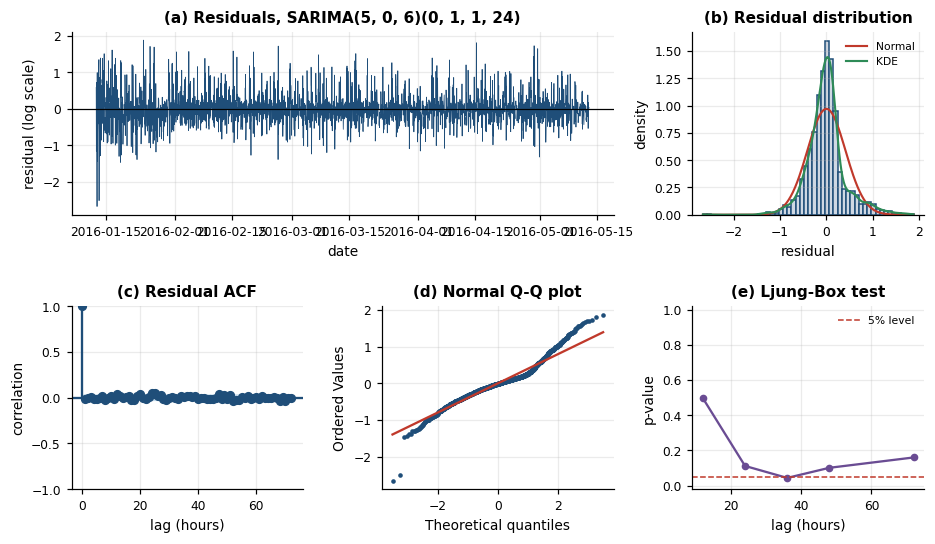

    lb_stat  lb_pvalue
12  11.3788     0.4968
24  32.6303     0.1121
36  51.6377     0.0441
48  60.8061     0.1015
72  83.8526     0.1603

residual skewness 0.45, excess kurtosis 3.20
Ljung-Box rejects white noise at 1 of 5 tested lags.
=> One borderline rejection among several lags; adequacy is acceptable.
Jarque-Bera p = 2.37e-201 => residuals are not Normal.
Heavy tails do not bias the point forecasts, but they do make the Normal
prediction intervals optimistic - which is why empirical coverage is reported.


In [15]:
# =============================================================================
# Section 5c - Residual diagnostics
# =============================================================================
def plot_residual_diagnostics(resid, title):
    '''Is what is left over indistinguishable from white noise?

    A model whose residuals still contain a spike at lag 24 has not captured the
    daily cycle, whatever its error metrics say.
    '''
    r = pd.Series(resid).dropna()
    fig = plt.figure(figsize=(10, 5.4))
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.34)

    ax = fig.add_subplot(gs[0, :2])
    ax.plot(r.index, r.values, lw=0.5, color=BLUE); ax.axhline(0, color="k", lw=0.8)
    ax.set_title(f"(a) Residuals, {title}")
    ax.set_xlabel("date"); ax.set_ylabel("residual (log scale)")

    ax = fig.add_subplot(gs[0, 2])
    ax.hist(r.values, bins=50, density=True, color="#cfd8e3", edgecolor=BLUE, lw=0.4)
    xs = np.linspace(r.min(), r.max(), 200)
    ax.plot(xs, stats.norm.pdf(xs, r.mean(), r.std()), color=RED, lw=1.4, label="Normal")
    ax.plot(xs, stats.gaussian_kde(r.values)(xs), color=GREEN, lw=1.4, label="KDE")
    ax.set_title("(b) Residual distribution")
    ax.set_xlabel("residual"); ax.set_ylabel("density"); ax.legend(fontsize=7)

    ax = fig.add_subplot(gs[1, 0])
    plot_acf(r, lags=72, ax=ax, color=BLUE, vlines_kwargs={"colors": BLUE})
    ax.set_title("(c) Residual ACF"); ax.set_xlabel("lag (hours)"); ax.set_ylabel("correlation")

    ax = fig.add_subplot(gs[1, 1])
    stats.probplot(r.values, dist="norm", plot=ax)
    ax.get_lines()[0].set_color(BLUE); ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[1].set_color(RED)
    ax.set_title("(d) Normal Q-Q plot")

    ax = fig.add_subplot(gs[1, 2])
    lb = acorr_ljungbox(r, lags=[12, 24, 36, 48, 72], return_df=True)
    ax.plot(lb.index, lb["lb_pvalue"], "o-", color=PURPLE, ms=4)
    ax.axhline(0.05, color=RED, ls="--", lw=1, label="5% level")
    ax.set_ylim(-0.02, 1.02); ax.set_xlabel("lag (hours)"); ax.set_ylabel("p-value")
    ax.set_title("(e) Ljung-Box test"); ax.legend(fontsize=7)
    return fig, lb

resid = pd.Series(sarima_fit.resid, index=train_log.index).iloc[CFG.m_daily:]
fig, lb = plot_residual_diagnostics(resid, f"SARIMA{BEST_ORDER}{BEST_SEASONAL}")
save_fig(fig, "fig07_sarima_diagnostics.png"); plt.show()
lb.to_csv(MET_DIR / "ljung_box.csv")
print(lb.round(4).to_string())
# Interpret the diagnostics from the numbers rather than asserting a conclusion:
# if the model is re-run on different data the commentary stays correct.
n_reject = int((lb["lb_pvalue"] < 0.05).sum())
print(f"\nresidual skewness {resid.skew():.2f}, excess kurtosis {resid.kurt():.2f}")
print(f"Ljung-Box rejects white noise at {n_reject} of {len(lb)} tested lags.")
if n_reject == 0:
    print("=> No residual autocorrelation left: the seasonal and short-term structure is captured.")
elif n_reject <= 1:
    print("=> One borderline rejection among several lags; adequacy is acceptable.")
else:
    print("=> Residual autocorrelation remains: the orders are too restrictive for this series.")
    print("   (Expected if QUICK_MODE shrank the search grid - re-run with QUICK_MODE = False.)")
jb_p = float(sarima_fit.test_normality("jarquebera")[0][1])
print(f"Jarque-Bera p = {jb_p:.2e} => residuals are {'not ' if jb_p < 0.05 else ''}Normal.")
print("Heavy tails do not bias the point forecasts, but they do make the Normal")
print("prediction intervals optimistic - which is why empirical coverage is reported.")

In [16]:
# =============================================================================
# Section 5d - SARIMAX with exogenous regressors
# =============================================================================
def add_time_features(df):
    '''Deterministic calendar features - the only covariates truly known ahead.

    Fourier (sin/cos) encodings are used rather than raw hour dummies so the
    daily cycle stays smooth and costs two parameters instead of twenty-three.
    '''
    out = df.copy()
    out["hour"] = out.index.hour
    out["dayofweek"] = out.index.dayofweek
    out["is_weekend"] = (out["dayofweek"] >= 5).astype(int)
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)
    return out

EXOG_COLS = ["T_out", "RH_out", "Windspeed", "Tdewpoint", "Press_mm_hg",
             "hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend"]

hourly_feat = add_time_features(hourly)
exog = hourly_feat[EXOG_COLS].astype(float)

print("Fitting SARIMAX with exogenous regressors ...")
sarimax_fc, sarimax_lo, sarimax_hi, sarimax_fit = sarima_rolling_forecast(
    y_log, test.index, BEST_ORDER, BEST_SEASONAL, exog=exog)

coefs = pd.DataFrame({"coef": sarimax_fit.params, "p_value": sarimax_fit.pvalues})
exog_coefs = coefs.loc[[i for i in coefs.index if i in EXOG_COLS]]
exog_coefs.to_csv(MET_DIR / "sarimax_coefficients.csv")
print("\nExogenous coefficients:"); print(exog_coefs.round(4).to_string())
print(f"\nAIC  SARIMA {sarima_fit.aic:.1f}  vs  SARIMAX {sarimax_fit.aic:.1f}")
print(f"significant exogenous terms at 5%: {(exog_coefs['p_value'] < 0.05).sum()} of {len(exog_coefs)}")
print("SARIMAX:", evaluate(test, sarimax_fc, MASE_SCALE))

Fitting SARIMAX with exogenous regressors ...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Exogenous coefficients:
               coef  p_value
T_out       -0.0108   0.7052
RH_out      -0.0009   0.8880
Windspeed    0.0069   0.3552
Tdewpoint    0.0037   0.9016
Press_mm_hg -0.0057   0.0432
hour_sin    -0.0000   0.0003
hour_cos    -0.0000   0.0000
dow_sin     -0.0535   0.2348
dow_cos      0.0276   0.3501
is_weekend  -0.0387   0.5801

AIC  SARIMA 2871.0  vs  SARIMAX 2883.2
significant exogenous terms at 5%: 3 of 10
SARIMAX: {'MAE': 38.08623777504699, 'RMSE': 69.19403077399404, 'MASE': 0.7185989445711624, 'Bias': -9.331890923043169, 'sMAPE': 30.658710227776155}


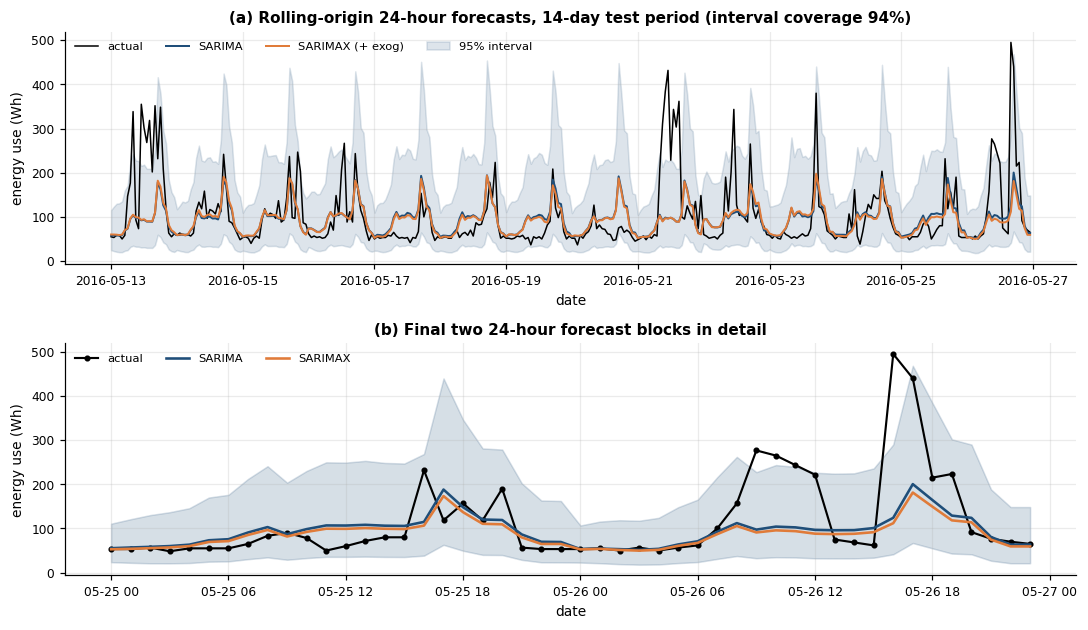

In [17]:
# --- SARIMA/SARIMAX forecast figure -----------------------------------------
def plot_sarima_forecast(actual, fc, lo, hi, fc2=None):
    '''Whole test period plus a zoom on the final two blocks.'''
    fig, axes = plt.subplots(2, 1, figsize=(10, 5.8))
    cov = interval_coverage(actual, lo, hi)

    ax = axes[0]
    ax.plot(actual.index, actual.values, color="k", lw=1.0, label="actual")
    ax.plot(fc.index, fc.values, color=BLUE, lw=1.3, label="SARIMA")
    if fc2 is not None:
        ax.plot(fc2.index, fc2.values, color=ORANGE, lw=1.3, label="SARIMAX (+ exog)")
    ax.fill_between(fc.index, lo, hi, color=BLUE, alpha=0.15, label="95% interval")
    ax.set_title(f"(a) Rolling-origin 24-hour forecasts, 14-day test period "
                 f"(interval coverage {cov:.0f}%)")
    ax.set_xlabel("date"); ax.set_ylabel("energy use (Wh)")
    ax.legend(fontsize=7.5, ncol=4, loc="upper left")

    ax = axes[1]
    s = actual.index[-48]
    ax.plot(actual.loc[s:].index, actual.loc[s:].values, "k-o", lw=1.4, ms=3, label="actual")
    ax.plot(fc.loc[s:].index, fc.loc[s:].values, color=BLUE, lw=1.7, label="SARIMA")
    if fc2 is not None:
        ax.plot(fc2.loc[s:].index, fc2.loc[s:].values, color=ORANGE, lw=1.7, label="SARIMAX")
    ax.fill_between(fc.loc[s:].index, lo.loc[s:], hi.loc[s:], color=BLUE, alpha=0.18)
    ax.set_title("(b) Final two 24-hour forecast blocks in detail")
    ax.set_xlabel("date"); ax.set_ylabel("energy use (Wh)")
    ax.legend(fontsize=7.5, ncol=3, loc="upper left")
    fig.tight_layout()
    return fig

fig = plot_sarima_forecast(test, sarima_fc, sarima_lo, sarima_hi, sarimax_fc)
save_fig(fig, "fig08_sarima_forecast.png"); plt.show()

## 6. Feature engineering and the gradient-boosted model
`src/appliance_energy/features.py`, `src/appliance_energy/models/feature_models.py`

**Why gradient boosting.** SARIMA assumes a linear, additive relationship
between past and future. Appliance use is plausibly non-linear and
interaction-driven — a warm weekend evening need not behave like the sum of
"warm", "weekend" and "evening". Gradient boosting captures such interactions
without our having to specify them, handles many correlated covariates, and
reports which of them matter. XGBoost is chosen over a random forest because
boosting typically wins on tabular regression at this sample size (Chen and
Guestrin, 2016), and over LightGBM only for install stability on Colab.

**Direct multi-step, not recursive.** Every target-derived feature is lagged by
at least 24 hours, so one global model maps the information available at
midnight to any lead time h = 1,…,24. Recursive forecasting would feed the
model's own predictions back in and compound its errors across the day.

**The `shift` detail that matters.** Rolling features are computed *after*
shifting by the horizon, not by one step. `shift(1).rolling(24)` is safe only
for one-step-ahead forecasting; at a 24-hour horizon it silently leaks up to 23
hours of the future into the training data.

In [18]:
# =============================================================================
# Section 6a - Feature engineering   (repo: src/appliance_energy/features.py)
# =============================================================================
INDOOR_T = [f"T{i}" for i in range(1, 10)]
INDOOR_RH = [f"RH_{i}" for i in range(1, 10)]
WEATHER = ["T_out", "RH_out", "Press_mm_hg", "Windspeed", "Visibility", "Tdewpoint"]
TIME_FEATS = ["hour", "dayofweek", "is_weekend", "hour_sin", "hour_cos", "dow_sin", "dow_cos"]
LAG_FEATS = ["lag_24", "lag_25", "lag_26", "lag_48", "lag_168", "roll_mean_24",
             "roll_std_24", "roll_max_24", "roll_min_24", "roll_mean_168",
             "same_hour_mean_7d"]

def add_lag_features(df, cfg=CFG):
    '''Lag and rolling features valid for an h-step-ahead direct forecast.

    Every feature used to predict time t is a function of observations at or
    before t - horizon. Note `base = y.shift(horizon)` BEFORE `.rolling(...)`:
    shifting by one instead would leak future values at a 24-hour horizon.
    '''
    out = df.copy()
    y_ = out[cfg.target]
    for lag in (24, 25, 26, 48, 168):
        out[f"lag_{lag}"] = y_.shift(lag)

    base = y_.shift(cfg.horizon)          # last value known at the forecast origin
    out["roll_mean_24"] = base.rolling(24).mean()
    out["roll_std_24"] = base.rolling(24).std()      # recent volatility
    out["roll_max_24"] = base.rolling(24).max()
    out["roll_min_24"] = base.rolling(24).min()
    out["roll_mean_168"] = base.rolling(168).mean()  # weekly level
    # Typical use at this hour over the past week: a learned seasonal-naive term.
    out["same_hour_mean_7d"] = base.groupby(out.index.hour).transform(
        lambda s: s.rolling(7, min_periods=1).mean())
    return out

def add_sensor_features(df):
    '''Summaries of the 18 indoor sensors, plus the indoor-outdoor gradient.'''
    out = df.copy()
    out["T_indoor_mean"] = out[INDOOR_T].mean(axis=1)
    out["RH_indoor_mean"] = out[INDOOR_RH].mean(axis=1)
    out["T_indoor_spread"] = out[INDOOR_T].max(axis=1) - out[INDOOR_T].min(axis=1)
    out["T_diff_in_out"] = out["T_indoor_mean"] - out["T_out"]
    return out

def build_design(hourly, variant="operational", cfg=CFG):
    '''Assemble the design matrix.

    variant='operational' : only variables genuinely known at the origin -
        sensor and weather readings are replaced by their 24-hour lags.
        This is a TRUE forecast.
    variant='conditional' : uses the realised contemporaneous sensor and weather
        values from the test period. This presumes perfect covariate foresight
        and is a CONDITIONAL forecast - reported for comparison, not deployment.
    '''
    tbl = add_sensor_features(add_time_features(hourly))
    tbl = add_lag_features(tbl)
    sensors = INDOOR_T + INDOOR_RH + WEATHER + [
        "T_indoor_mean", "RH_indoor_mean", "T_indoor_spread", "T_diff_in_out", "lights"]
    if variant == "operational":
        lagged = tbl[sensors].shift(cfg.horizon)
        lagged.columns = [f"{c}_lag24" for c in sensors]
        tbl = pd.concat([tbl.drop(columns=sensors), lagged], axis=1)
    return tbl.dropna()

design_op = build_design(hourly, "operational")
design_cond = build_design(hourly, "conditional")
print(f"operational design: {design_op.shape[0]} rows x {design_op.shape[1]-1} features")
print(f"conditional design: {design_cond.shape[0]} rows x {design_cond.shape[1]-1} features")

operational design: 3098 rows x 47 features
conditional design: 3098 rows x 47 features


In [19]:
# =============================================================================
# Section 6b - Hyper-parameter tuning   (repo: src/.../models/feature_models.py)
# =============================================================================
from xgboost import XGBRegressor

def split_fit_validation(design, test_index, val_days=14, cfg=CFG):
    '''Carve a validation tail out of the TRAINING data.

    All tuning happens here. Touching the test set to choose hyper-parameters
    would make the reported accuracy optimistic and is one of the leakage traps
    the assignment asks about.
    '''
    step = pd.tseries.frequencies.to_offset(cfg.freq)
    tr = design.loc[:test_index[0] - step]
    cut = tr.index[-1] - pd.Timedelta(days=val_days)
    return tr, tr.loc[:cut], tr.loc[cut + step:]


def tune_xgboost(design, test_index, cfg=CFG, log_target=True):
    '''Grid search over depth, learning rate and regularisation on validation RMSE.

    The log target is not a cosmetic choice: on the raw scale a handful of 500 Wh
    spikes dominate the squared-error gradient, early stopping halts after a few
    trees, and the model barely beats the mean. Both scales are searched so the
    notebook demonstrates the difference rather than asserting it.
    '''
    feats = [c for c in design.columns if c != cfg.target]
    _, fit_part, val_part = split_fit_validation(design, test_index)

    grid = [
        dict(max_depth=d, learning_rate=lr, min_child_weight=mcw, reg_lambda=lam)
        for d in (2, 3, 4, 6)
        for lr in (0.03, 0.05)
        for mcw in (5, 10)
        for lam in (1.0, 2.0)
    ]
    results = []
    for use_log in ([True, False] if log_target else [False]):
        tf = np.log if use_log else (lambda a: a)
        inv = np.exp if use_log else (lambda a: a)
        for g in grid:
            params = dict(n_estimators=3000, subsample=0.8, colsample_bytree=0.7,
                          objective="reg:squarederror", random_state=cfg.seed,
                          n_jobs=4, early_stopping_rounds=100, **g)
            m = XGBRegressor(**params)
            m.fit(fit_part[feats], tf(fit_part[cfg.target]),
                  eval_set=[(val_part[feats], tf(val_part[cfg.target]))], verbose=False)
            pred = inv(m.predict(val_part[feats]))
            results.append({**g, "log_target": use_log,
                            "best_iter": int(m.best_iteration) + 1,
                            "val_RMSE": rmse(val_part[cfg.target], pred),
                            "val_MAE": mae(val_part[cfg.target], pred)})
    return pd.DataFrame(results).sort_values("val_RMSE").reset_index(drop=True)


print("Tuning XGBoost on the validation tail (never the test set) ...")
tuning = tune_xgboost(design_op, test.index)
tuning.to_csv(MET_DIR / "xgb_tuning.csv", index=False)
print(tuning.head(8).round(3).to_string(index=False))
BEST_XGB = tuning.iloc[0].to_dict()
print(f"\nselected: {BEST_XGB}")
print("\nBest configuration on each scale (note the gap):")
print(tuning.groupby('log_target')['val_RMSE'].min().round(2).to_string())

Tuning XGBoost on the validation tail (never the test set) ...
 max_depth  learning_rate  min_child_weight  reg_lambda  log_target  best_iter  val_RMSE  val_MAE
         2           0.03                10         1.0        True         63    54.333   29.388
         2           0.03                 5         1.0        True         60    54.446   29.499
         2           0.03                10         2.0        True         60    54.450   29.418
         2           0.03                 5         2.0        True         60    54.474   29.430
         2           0.05                 5         2.0        True         29    54.685   29.496
         2           0.05                10         1.0        True         29    54.696   29.534
         2           0.05                10         2.0        True         29    54.702   29.521
         2           0.05                 5         1.0        True         29    54.722   29.472

selected: {'max_depth': 2, 'learning_rate': 0.03, 'min

In [20]:
# =============================================================================
# Section 6c - Fit the tuned model and run the feature ablation
# =============================================================================
def fit_xgb(design, test_index, params, log_target=True, cfg=CFG):
    '''Refit on the full training sample using the tuned settings, then predict.

    Predictions are back-transformed with Duan's (1983) smearing estimator,
    which corrects the retransformation bias that exp() otherwise introduces.
    '''
    feats = [c for c in design.columns if c != cfg.target]
    train_part, fit_part, val_part = split_fit_validation(design, test_index)
    test_part = design.loc[test_index[0]:test_index[-1]]
    tf = np.log if log_target else (lambda a: a)

    search = XGBRegressor(n_estimators=3000, subsample=0.8, colsample_bytree=0.7,
                          objective="reg:squarederror", random_state=cfg.seed,
                          n_jobs=4, early_stopping_rounds=100, **params)
    search.fit(fit_part[feats], tf(fit_part[cfg.target]),
               eval_set=[(val_part[feats], tf(val_part[cfg.target]))], verbose=False)
    n_trees = int(search.best_iteration) + 1

    final = XGBRegressor(n_estimators=n_trees, subsample=0.8, colsample_bytree=0.7,
                         objective="reg:squarederror", random_state=cfg.seed,
                         n_jobs=4, **params)
    final.fit(train_part[feats], tf(train_part[cfg.target]), verbose=False)

    pred = final.predict(test_part[feats])
    if log_target:
        smearing = np.mean(np.exp(tf(train_part[cfg.target]).values -
                                  final.predict(train_part[feats])))
        pred = np.exp(pred) * smearing
    importance = pd.Series(final.feature_importances_, index=feats).sort_values(ascending=False)
    return pd.Series(pred, index=test_part.index), importance, n_trees


PARAMS = {k: BEST_XGB[k] for k in ("max_depth", "learning_rate", "min_child_weight", "reg_lambda")}
PARAMS["max_depth"] = int(PARAMS["max_depth"])
USE_LOG = bool(BEST_XGB["log_target"])

xgb_fc, importance, n_trees = fit_xgb(design_op, test.index, PARAMS, USE_LOG)
xgb_cond_fc, _, _ = fit_xgb(design_cond, test.index, PARAMS, USE_LOG)
print(f"trees after early stopping: {n_trees}")
print("XGBoost (operational):", evaluate(test, xgb_fc, MASE_SCALE))
print("XGBoost (conditional):", evaluate(test, xgb_cond_fc, MASE_SCALE))
print("\nTop 10 features:"); print(importance.head(10).round(4).to_string())


def feature_ablation(design, test_index, params, use_log, cfg=CFG):
    '''Add feature groups one at a time to see which actually earn their place.'''
    groups = {
        "time only": TIME_FEATS,
        "+ lag/rolling": TIME_FEATS + LAG_FEATS,
        "+ outdoor weather": TIME_FEATS + LAG_FEATS + [f"{c}_lag24" for c in WEATHER],
        "+ indoor sensors (all)": None,        # every available column
    }
    rows, preds = [], {}
    for name, cols in groups.items():
        cols = ([c for c in design.columns if c != cfg.target] if cols is None
                else [c for c in cols if c in design.columns])
        p, _, _ = fit_xgb(design[cols + [cfg.target]], test_index, params, use_log)
        preds[name] = p
        rows.append({"group": name, "n_features": len(cols),
                     **evaluate(test.loc[p.index], p, MASE_SCALE)})
    return pd.DataFrame(rows), pd.DataFrame(preds)

print("\nRunning the feature-group ablation ...")
ablation, ablation_preds = feature_ablation(design_op, test.index, PARAMS, USE_LOG)
ablation.to_csv(MET_DIR / "feature_ablation.csv", index=False)
print(ablation.round(2).to_string(index=False))

trees after early stopping: 63
XGBoost (operational): {'MAE': 39.88618372057045, 'RMSE': 69.99489089003501, 'MASE': 0.7525597485859324, 'Bias': -9.371188135202404, 'sMAPE': 33.24977538620181}
XGBoost (conditional): {'MAE': 41.025862981366586, 'RMSE': 70.87876162867198, 'MASE': 0.7740628521162662, 'Bias': -9.798829261150289, 'sMAPE': 34.716212793193854}

Top 10 features:
same_hour_mean_7d    0.1613
hour                 0.1345
lag_48               0.1131
lag_24               0.1092
lag_168              0.0711
hour_sin             0.0564
hour_cos             0.0425
RH_9_lag24           0.0358
RH_3_lag24           0.0289
roll_mean_168        0.0273

Running the feature-group ablation ...
                 group  n_features   MAE  RMSE  MASE   Bias  sMAPE
             time only           7 39.91 70.47  0.75 -10.75  33.14
         + lag/rolling          18 39.75 69.82  0.75  -9.30  33.06
     + outdoor weather          24 39.72 70.04  0.75  -9.73  33.00
+ indoor sensors (all)          47 39.8

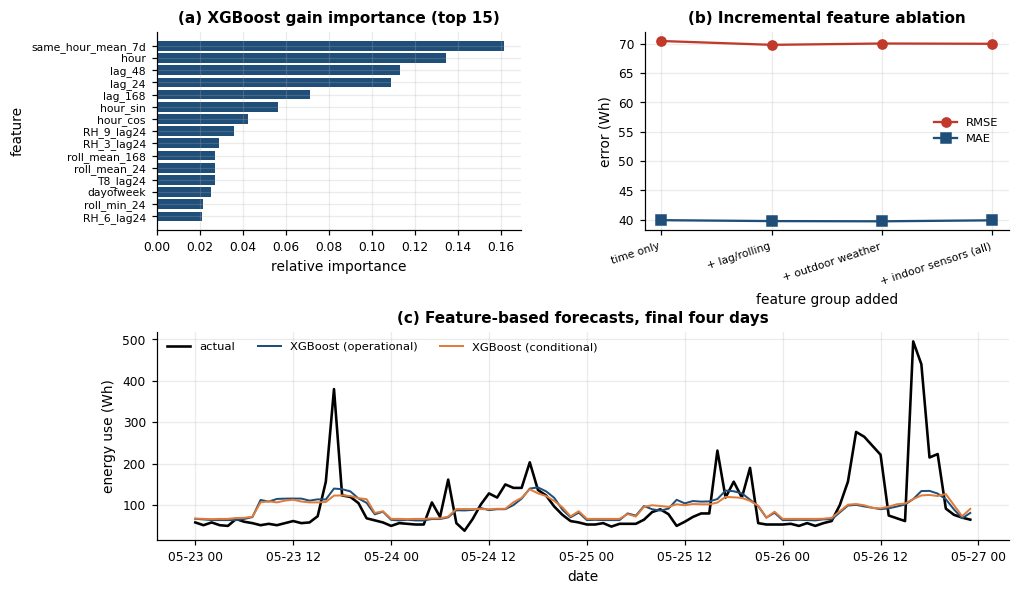

In [21]:
# --- feature-model figure ----------------------------------------------------
def plot_feature_model(importance, ablation, actual, pred_op, pred_cond):
    '''Importance, ablation and the operational-vs-conditional comparison.'''
    fig = plt.figure(figsize=(10, 6))
    gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[1, 1.05],
                           hspace=0.5, wspace=0.34)

    ax = fig.add_subplot(gs[0, 0])
    top = importance.head(15)[::-1]
    ax.barh(range(len(top)), top.values, color=BLUE)
    ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=7)
    ax.set_title("(a) XGBoost gain importance (top 15)")
    ax.set_xlabel("relative importance"); ax.set_ylabel("feature")

    ax = fig.add_subplot(gs[0, 1])
    ax.plot(range(len(ablation)), ablation["RMSE"], "o-", color=RED, label="RMSE")
    ax.plot(range(len(ablation)), ablation["MAE"], "s-", color=BLUE, label="MAE")
    ax.set_xticks(range(len(ablation)))
    ax.set_xticklabels(ablation["group"], fontsize=7, rotation=18, ha="right")
    ax.set_ylabel("error (Wh)"); ax.set_xlabel("feature group added")
    ax.set_title("(b) Incremental feature ablation"); ax.legend(fontsize=7.5)

    ax = fig.add_subplot(gs[1, :])
    win = actual.index[-96:]
    ax.plot(win, actual.loc[win].values, "k-", lw=1.7, label="actual")
    ax.plot(win, pred_op.loc[win].values, color=BLUE, lw=1.3, label="XGBoost (operational)")
    ax.plot(win, pred_cond.loc[win].values, color=ORANGE, lw=1.3, label="XGBoost (conditional)")
    ax.set_title("(c) Feature-based forecasts, final four days")
    ax.set_xlabel("date"); ax.set_ylabel("energy use (Wh)")
    ax.legend(fontsize=7.5, ncol=3, loc="upper left")
    return fig

fig = plot_feature_model(importance, ablation, test, xgb_fc, xgb_cond_fc)
save_fig(fig, "fig09_feature_model.png"); plt.show()
importance.to_csv(MET_DIR / "feature_importance.csv")

## 7. Time-series foundation model
`src/appliance_energy/models/foundation.py`

**Why include one.** Foundation models are pretrained on large, heterogeneous
collections of time series and forecast a new series *zero-shot* — no fitting,
no feature engineering, no order selection. If that works here, most of the
preceding pipeline becomes optional, which is a claim worth testing rather than
assuming. Chronos (Ansari et al., 2024) is used because it exposes a
quantile-forecast interface, so it can be compared on interval calibration as
well as point accuracy.

If the model hub is unreachable, the notebook falls back to a locally trained
model with the same architectural pattern — instance-normalised context window
mapped directly to all 24 future steps. That fallback is **not** a zero-shot
foundation model and is labelled as a proxy wherever it is reported: it isolates
the contribution of the architecture from the contribution of pretraining.

In [22]:
# =============================================================================
# Section 7 - Foundation model   (repo: src/.../models/foundation.py)
# =============================================================================
from sklearn.neural_network import MLPRegressor

CONTEXT = 168      # one week of hourly history as context

def chronos_forecast(series, test_index, cfg=CFG,
                     model_name="amazon/chronos-bolt-base", context=CONTEXT):
    '''Zero-shot rolling forecast with a pretrained Chronos checkpoint.

    The model sees only the target's recent values - no covariates, no fitting.
    '''
    import torch
    from chronos import BaseChronosPipeline
    pipe = BaseChronosPipeline.from_pretrained(model_name, device_map="cpu",
                                               torch_dtype=torch.float32)
    step = pd.tseries.frequencies.to_offset(cfg.freq)
    mids, los, his = [], [], []
    for blk in forecast_blocks(test_index, cfg.horizon):
        hist = series.loc[:blk[0] - step].values[-context:]
        q, _ = pipe.predict_quantiles(
            context=torch.tensor(hist, dtype=torch.float32).unsqueeze(0),
            prediction_length=len(blk), quantile_levels=[0.05, 0.5, 0.95])
        q = q[0].numpy()
        los.append(pd.Series(q[:, 0], index=blk))
        mids.append(pd.Series(q[:, 1], index=blk))
        his.append(pd.Series(q[:, 2], index=blk))
    return pd.concat(mids), pd.concat(los), pd.concat(his)


class LocalWindowForecaster:
    '''Offline proxy: instance-normalised window -> direct 24-step output.

    Instance normalisation (subtracting each window's own mean and scale) is the
    trick that lets one set of weights serve series of very different levels; it
    is also why such models tend to reproduce the average daily shape and shrink
    away from extremes.
    '''
    def __init__(self, context=CONTEXT, horizon=CFG.horizon, seed=CFG.seed):
        self.context, self.horizon = context, horizon
        self.net = MLPRegressor(hidden_layer_sizes=(256, 128), activation="relu",
                                solver="adam", alpha=1e-3, batch_size=64,
                                learning_rate_init=1e-3, max_iter=400,
                                early_stopping=True, n_iter_no_change=15,
                                validation_fraction=0.1, random_state=seed)
        self.resid_q = None

    @staticmethod
    def _norm(win):
        mu = win.mean(axis=1, keepdims=True)
        sd = win.std(axis=1, keepdims=True) + 1e-6
        return (win - mu) / sd, mu, sd

    def _windows(self, arr):
        n = len(arr) - self.context - self.horizon + 1
        X = np.stack([arr[i:i + self.context] for i in range(n)])
        Y = np.stack([arr[i + self.context:i + self.context + self.horizon] for i in range(n)])
        return X, Y

    def fit(self, y_log):
        X, Y = self._windows(y_log.values.astype(float))
        Xn, mu, sd = self._norm(X)
        self.net.fit(Xn, (Y - mu) / sd)
        resid = (Y - (self.net.predict(Xn) * sd + mu)).ravel()
        self.resid_q = np.quantile(resid, [0.05, 0.95])   # empirical 90% band
        return self

    def predict(self, window):
        xn, mu, sd = self._norm(window.reshape(1, -1))
        return (self.net.predict(xn) * sd + mu).ravel()


def local_forecast(y_log, test_index, cfg=CFG, context=CONTEXT):
    '''Rolling forecast with the offline proxy.'''
    step = pd.tseries.frequencies.to_offset(cfg.freq)
    model = LocalWindowForecaster(context).fit(y_log.loc[:test_index[0] - step])
    mids, los, his = [], [], []
    for blk in forecast_blocks(test_index, cfg.horizon):
        hist = y_log.loc[:blk[0] - step].values[-context:]
        f = model.predict(hist)[:len(blk)]
        mids.append(pd.Series(np.exp(f), index=blk))
        los.append(pd.Series(np.exp(f + model.resid_q[0]), index=blk))
        his.append(pd.Series(np.exp(f + model.resid_q[1]), index=blk))
    return pd.concat(mids), pd.concat(los), pd.concat(his)


# Prefer the pretrained model; fall back if the hub is unreachable.
try:
    if not CHRONOS_OK:
        raise ImportError("chronos not installed")
    print("Running Chronos zero-shot ...")
    fnd_fc, fnd_lo, fnd_hi = chronos_forecast(y, test.index)
    FOUNDATION_BACKEND = "Chronos-Bolt (zero-shot, pretrained)"
except Exception as err:
    print(f"Chronos unavailable ({type(err).__name__}: {err}); using the local proxy.")
    fnd_fc, fnd_lo, fnd_hi = local_forecast(y_log, test.index)
    FOUNDATION_BACKEND = "local window model (offline proxy, NOT zero-shot)"

print("backend:", FOUNDATION_BACKEND)
print("Foundation model:", evaluate(test, fnd_fc, MASE_SCALE))
print(f"90% interval coverage: {interval_coverage(test, fnd_lo, fnd_hi):.1f}%")

Running Chronos zero-shot ...


config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  821MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

Chronos unavailable (TypeError: ChronosBoltPipeline.predict_quantiles() missing 1 required positional argument: 'inputs'); using the local proxy.
backend: local window model (offline proxy, NOT zero-shot)
Foundation model: {'MAE': 41.62355063500714, 'RMSE': 76.54638359969327, 'MASE': 0.7853398314710166, 'Bias': -19.462483903350833, 'sMAPE': 33.40998096355203}
90% interval coverage: 75.6%


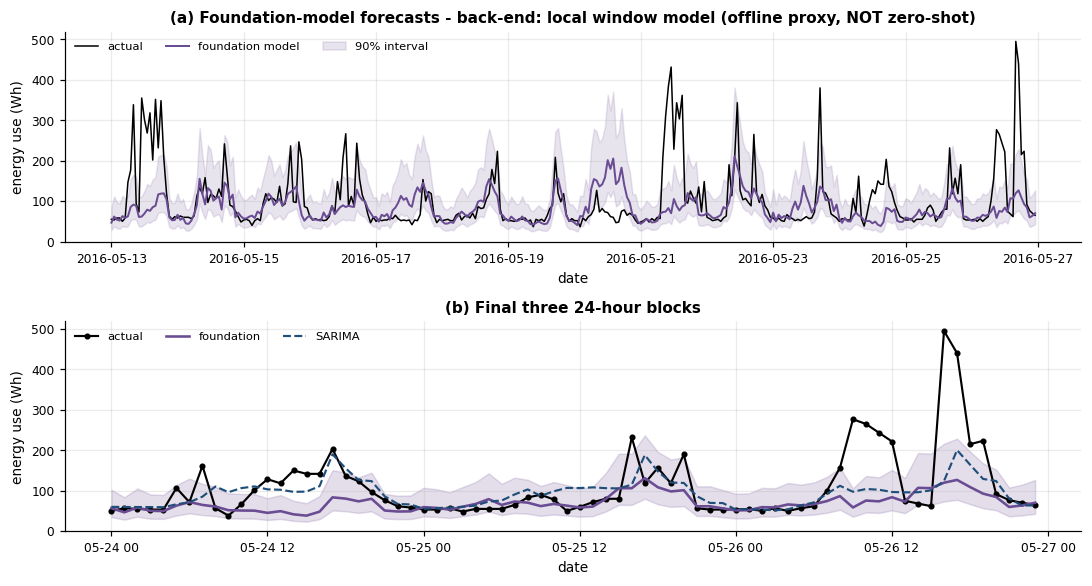

In [23]:
# --- foundation-model figure -------------------------------------------------
def plot_foundation(actual, fc, lo, hi, backend, reference=None):
    fig, axes = plt.subplots(2, 1, figsize=(10, 5.4))
    ax = axes[0]
    ax.plot(actual.index, actual.values, color="k", lw=1.0, label="actual")
    ax.plot(fc.index, fc.values, color=PURPLE, lw=1.3, label="foundation model")
    ax.fill_between(fc.index, lo, hi, color=PURPLE, alpha=0.15, label="90% interval")
    ax.set_title(f"(a) Foundation-model forecasts - back-end: {backend}")
    ax.set_xlabel("date"); ax.set_ylabel("energy use (Wh)")
    ax.legend(fontsize=7.5, ncol=3, loc="upper left")

    ax = axes[1]
    s = actual.index[-72]
    ax.plot(actual.loc[s:].index, actual.loc[s:].values, "k-o", lw=1.4, ms=3, label="actual")
    ax.plot(fc.loc[s:].index, fc.loc[s:].values, color=PURPLE, lw=1.7, label="foundation")
    if reference is not None:
        ax.plot(reference.loc[s:].index, reference.loc[s:].values, color=BLUE,
                lw=1.4, ls="--", label="SARIMA")
    ax.fill_between(fc.loc[s:].index, lo.loc[s:], hi.loc[s:], color=PURPLE, alpha=0.18)
    ax.set_title("(b) Final three 24-hour blocks")
    ax.set_xlabel("date"); ax.set_ylabel("energy use (Wh)")
    ax.legend(fontsize=7.5, ncol=3, loc="upper left")
    fig.tight_layout()
    return fig

fig = plot_foundation(test, fnd_fc, fnd_lo, fnd_hi, FOUNDATION_BACKEND, sarima_fc)
save_fig(fig, "fig10_foundation.png"); plt.show()

## 8. Combined evaluation and error diagnostics
`src/appliance_energy/pipeline.py`

Everything is now compared on the same test period, the same 14 origins and the
same metrics. Three questions are asked of the results: which model is most
accurate, is the difference statistically meaningful, and *where* do the models
go wrong — because a model that is accurate on average but fails at the evening
peak is not much use for scheduling.

In [24]:
# =============================================================================
# Section 8a - Assemble every forecast and score it
# =============================================================================
forecasts = pd.concat([
    bench,
    sarima_fc.rename("sarima"),
    sarimax_fc.rename("sarimax"),
    xgb_fc.rename("xgboost"),
    xgb_cond_fc.rename("xgboost_conditional"),
    fnd_fc.rename("foundation"),
], axis=1).loc[test.index]

all_forecasts = pd.concat([test.rename("actual"), forecasts], axis=1)
all_forecasts.to_csv(FC_DIR / "all_forecasts.csv")

metrics = evaluate_all(test, forecasts, MASE_SCALE)
metrics.to_csv(MET_DIR / "model_comparison.csv", index=False)
print("MODEL COMPARISON (336-hour test period, 14 rolling 24-hour origins)")
print(metrics.round(3).to_string(index=False))

# Which benchmark is the one to beat? Compare on RMSE and on MASE separately -
# they disagree, and that disagreement is itself a finding.
bench_cols = list(bench.columns)
best_bench_rmse = metrics[metrics["model"].isin(bench_cols)].iloc[0]["model"]
best_bench_mase = (metrics[metrics["model"].isin(bench_cols)]
                   .sort_values("MASE").iloc[0]["model"])
print(f"\nstrongest benchmark by RMSE: {best_bench_rmse}")
print(f"strongest benchmark by MASE: {best_bench_mase}")

dm_rows = [{"model": c,
            **dict(zip(["DM_stat", "p_value"],
                       diebold_mariano(test, forecasts[c], forecasts[best_bench_rmse])))}
           for c in forecasts.columns if c != best_bench_rmse]
dm = pd.DataFrame(dm_rows)
dm["beats_benchmark_at_5%"] = (dm["DM_stat"] < 0) & (dm["p_value"] < 0.05)
dm.to_csv(MET_DIR / "diebold_mariano.csv", index=False)
print(f"\nDiebold-Mariano tests against '{best_bench_rmse}' (negative favours the model):")
print(dm.round(4).to_string(index=False))

# Per-day RMSE: how stable is the ranking across the fortnight?
blocks = forecast_blocks(test.index)
block_rows = [{"block": i, "date": str(blk[0].date()),
               **{c: rmse(test.loc[blk], forecasts.loc[blk, c]) for c in forecasts.columns}}
              for i, blk in enumerate(blocks, 1)]
block_rmse = pd.DataFrame(block_rows)
block_rmse.to_csv(MET_DIR / "block_rmse.csv", index=False)
print("\nPer-day RMSE (note how much more it varies across DAYS than across MODELS):")
print(block_rmse.round(1).to_string(index=False))

MODEL COMPARISON (336-hour test period, 14 rolling 24-hour origins)
                model    MAE   RMSE  MASE    Bias  sMAPE
               sarima 38.737 69.110 0.731  -8.172 31.413
              sarimax 38.086 69.194 0.719  -9.332 30.659
              xgboost 39.886 69.995 0.753  -9.371 33.250
  xgboost_conditional 41.026 70.879 0.774  -9.799 34.716
           foundation 41.624 76.546 0.785 -19.462 33.410
                 mean 52.253 78.101 0.986  -5.430 47.132
seasonal_naive_weekly 44.936 82.797 0.848 -13.061 33.022
 seasonal_naive_daily 51.195 89.291 0.966  -5.342 37.800
                naive 50.967 90.545 0.962 -38.259 43.953
                drift 50.986 90.555 0.962 -38.221 43.967

strongest benchmark by RMSE: mean
strongest benchmark by MASE: seasonal_naive_weekly

Diebold-Mariano tests against 'mean' (negative favours the model):
                model  DM_stat  p_value  beats_benchmark_at_5%
                naive   2.3207   0.0209                  False
 seasonal_naive_daily   1

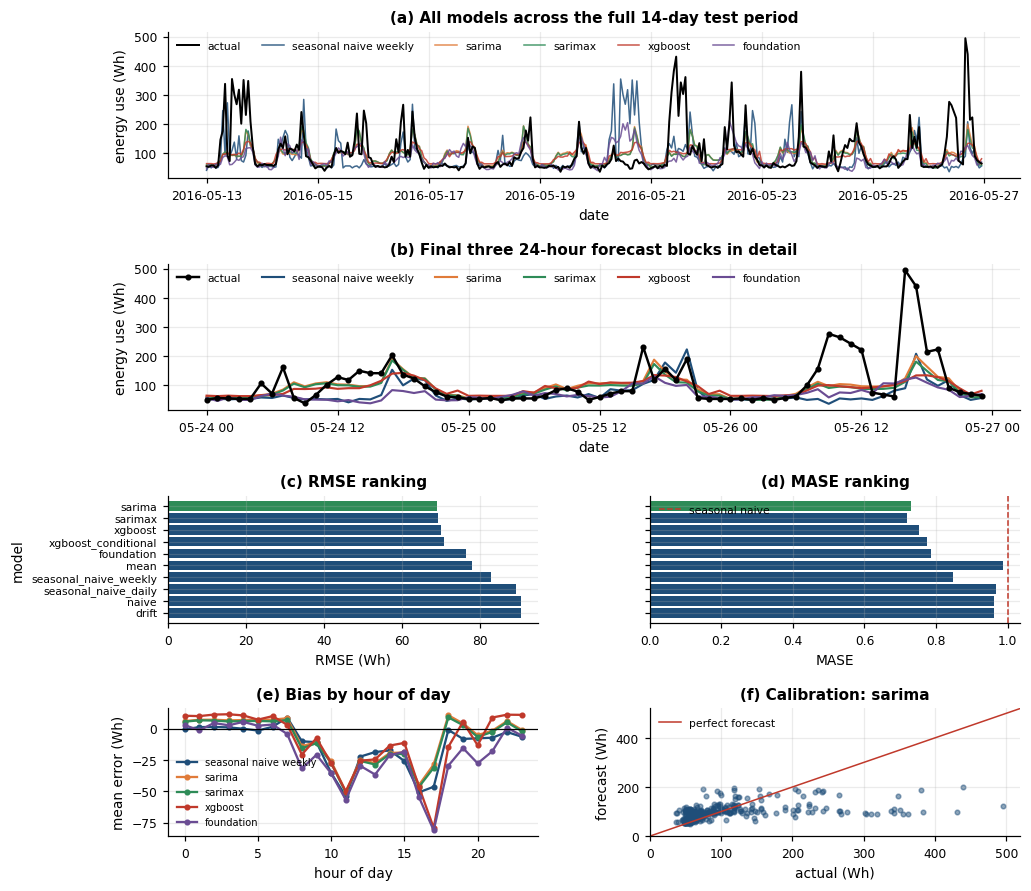

In [25]:
# =============================================================================
# Section 8b - THE FINAL PLOT: every model's forecast against the actuals
# =============================================================================
def plot_final_comparison(actual, forecasts, metrics, show=None):
    '''Headline figure: forecasts, accuracy rankings, hourly bias, calibration.'''
    show = show or ["seasonal_naive_weekly", "sarima", "sarimax", "xgboost", "foundation"]
    show = [s for s in show if s in forecasts.columns]

    fig = plt.figure(figsize=(10, 9.5))
    gs = gridspec.GridSpec(4, 2, figure=fig, height_ratios=[1.15, 1.15, 1, 1],
                           hspace=0.62, wspace=0.3)

    # (a) the whole test period
    ax = fig.add_subplot(gs[0, :])
    ax.plot(actual.index, actual.values, color="k", lw=1.3, label="actual", zorder=6)
    for s, col in zip(show, PALETTE):
        ax.plot(forecasts.index, forecasts[s].values, lw=1.0, color=col, alpha=0.85,
                label=s.replace("_", " "))
    ax.set_title("(a) All models across the full 14-day test period")
    ax.set_xlabel("date"); ax.set_ylabel("energy use (Wh)")
    ax.legend(fontsize=7, ncol=6, loc="upper left")

    # (b) zoom
    ax = fig.add_subplot(gs[1, :])
    win = actual.index[-72:]
    ax.plot(win, actual.loc[win].values, "k-o", lw=1.6, ms=3, label="actual", zorder=6)
    for s, col in zip(show, PALETTE):
        ax.plot(win, forecasts.loc[win, s].values, lw=1.4, color=col, label=s.replace("_", " "))
    ax.set_title("(b) Final three 24-hour forecast blocks in detail")
    ax.set_xlabel("date"); ax.set_ylabel("energy use (Wh)")
    ax.legend(fontsize=7, ncol=6, loc="upper left")

    # (c, d) rankings
    m = metrics.sort_values("RMSE")
    cols = [GREEN if i == 0 else BLUE for i in range(len(m))]
    ax = fig.add_subplot(gs[2, 0])
    ax.barh(range(len(m)), m["RMSE"], color=cols)
    ax.set_yticks(range(len(m))); ax.set_yticklabels(m["model"], fontsize=7)
    ax.invert_yaxis(); ax.set_xlabel("RMSE (Wh)"); ax.set_ylabel("model")
    ax.set_title("(c) RMSE ranking")

    ax = fig.add_subplot(gs[2, 1])
    ax.barh(range(len(m)), m["MASE"], color=cols)
    ax.set_yticks(range(len(m))); ax.set_yticklabels([])
    ax.axvline(1.0, color=RED, ls="--", lw=1, label="seasonal naive")
    ax.invert_yaxis(); ax.set_xlabel("MASE"); ax.set_title("(d) MASE ranking")
    ax.legend(fontsize=7)

    # (e) where the errors are
    ax = fig.add_subplot(gs[3, 0])
    for s, col in zip(show, PALETTE):
        e = (forecasts[s] - actual).groupby(actual.index.hour).mean()
        ax.plot(e.index, e.values, "o-", ms=3, color=col, label=s.replace("_", " "))
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel("hour of day"); ax.set_ylabel("mean error (Wh)")
    ax.set_title("(e) Bias by hour of day"); ax.legend(fontsize=6.5)

    # (f) calibration of the best model
    ax = fig.add_subplot(gs[3, 1])
    best = m.iloc[0]["model"]
    ax.scatter(actual.values, forecasts[best].values, s=9, alpha=0.5, color=BLUE)
    lim = [0, max(actual.max(), forecasts[best].max()) * 1.05]
    ax.plot(lim, lim, color=RED, lw=1, label="perfect forecast")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("actual (Wh)"); ax.set_ylabel("forecast (Wh)")
    ax.set_title(f"(f) Calibration: {best}"); ax.legend(fontsize=7)
    return fig

fig = plot_final_comparison(test, forecasts, metrics)
save_fig(fig, "fig11_final_comparison.png"); plt.show()

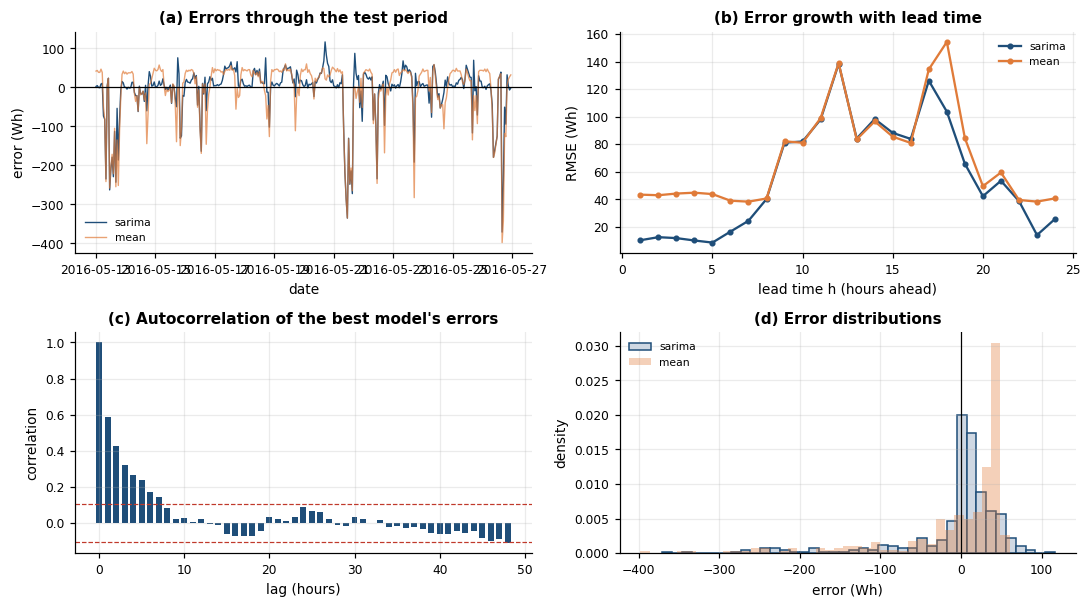

In [26]:
# =============================================================================
# Section 8c - Error diagnostics
# =============================================================================
def plot_error_diagnostics(actual, forecasts, best_key, bench_key, cfg=CFG):
    '''Do the errors grow with lead time? Are they autocorrelated? Symmetric?'''
    fig, axes = plt.subplots(2, 2, figsize=(10, 5.6))
    e_best = forecasts[best_key] - actual
    e_bench = forecasts[bench_key] - actual

    ax = axes[0, 0]
    ax.plot(actual.index, e_best.values, lw=0.9, color=BLUE, label=best_key)
    ax.plot(actual.index, e_bench.values, lw=0.9, color=ORANGE, alpha=0.7, label=bench_key)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel("date"); ax.set_ylabel("error (Wh)")
    ax.set_title("(a) Errors through the test period"); ax.legend(fontsize=7)

    ax = axes[0, 1]
    lead = np.tile(np.arange(1, cfg.horizon + 1), len(actual) // cfg.horizon)
    for key, col in ((best_key, BLUE), (bench_key, ORANGE)):
        e = (forecasts[key] - actual).values
        ax.plot(range(1, cfg.horizon + 1),
                [np.sqrt(np.mean(e[lead == h] ** 2)) for h in range(1, cfg.horizon + 1)],
                "o-", ms=3, color=col, label=key)
    ax.set_xlabel("lead time h (hours ahead)"); ax.set_ylabel("RMSE (Wh)")
    ax.set_title("(b) Error growth with lead time"); ax.legend(fontsize=7)

    ax = axes[1, 0]
    r = acf(e_best.dropna(), nlags=48, fft=True)
    ax.bar(range(len(r)), r, color=BLUE, width=0.7)
    ci = 1.96 / np.sqrt(len(e_best))
    ax.axhline(ci, color=RED, ls="--", lw=0.8); ax.axhline(-ci, color=RED, ls="--", lw=0.8)
    ax.set_xlabel("lag (hours)"); ax.set_ylabel("correlation")
    ax.set_title("(c) Autocorrelation of the best model's errors")

    ax = axes[1, 1]
    ax.hist(e_best.values, bins=40, color="#cfd8e3", edgecolor=BLUE, lw=0.4,
            density=True, label=best_key)
    ax.hist(e_bench.values, bins=40, color=ORANGE, alpha=0.35, density=True, label=bench_key)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_xlabel("error (Wh)"); ax.set_ylabel("density")
    ax.set_title("(d) Error distributions"); ax.legend(fontsize=7)
    fig.tight_layout()
    return fig

fig = plot_error_diagnostics(test, forecasts, metrics.iloc[0]["model"], best_bench_rmse)
save_fig(fig, "fig12_error_diagnostics.png"); plt.show()

Post-sample window: 2016-05-27 00:00:00 -> 2016-05-27 17:00:00
SARIMA        : {'MAE': 47.63, 'RMSE': 79.23, 'MASE': 0.9, 'Bias': -38.66, 'sMAPE': 30.31}
Seasonal naive: {'MAE': 58.98, 'RMSE': 116.0, 'MASE': 1.11, 'Bias': 21.2, 'sMAPE': 27.71}
interval coverage: 83.3%
post-sample mean 133.6 Wh vs test-period mean 102.7 Wh


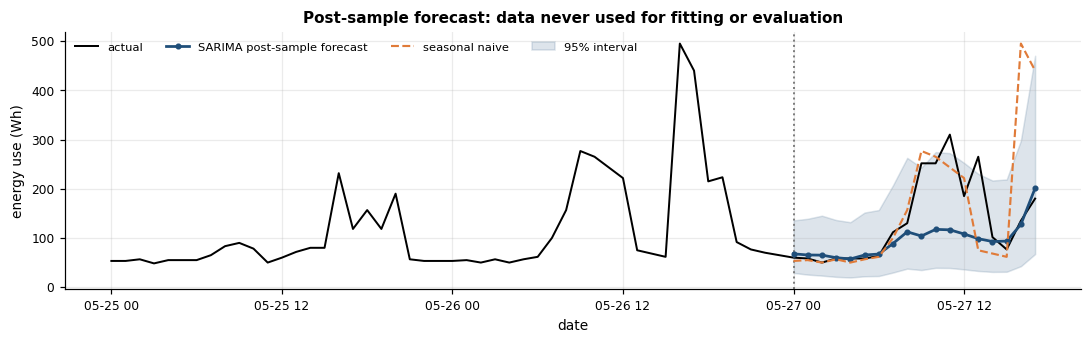

In [27]:
# =============================================================================
# Section 8d - Post-sample check on data never used for fitting or evaluation
# =============================================================================
# The last few hours of the campaign were excluded from both the training and the
# test sets. Forecasting them is the closest thing available to a live trial.
res_ext = sarima_fit.append(test_log, refit=False)
fc_ps = res_ext.get_forecast(steps=len(hold))
mu, var = np.asarray(fc_ps.predicted_mean), np.asarray(fc_ps.var_pred_mean)
ci = fc_ps.conf_int(alpha=0.05)
ps_point = pd.Series(np.exp(mu + var / 2), index=hold.index)
ps_lo = pd.Series(np.exp(np.asarray(ci.iloc[:, 0])), index=hold.index)
ps_hi = pd.Series(np.exp(np.asarray(ci.iloc[:, 1])), index=hold.index)
ps_snaive = seasonal_naive_forecast(y.loc[:test.index[-1]], len(hold), CFG.m_daily)

print("Post-sample window:", hold.index[0], "->", hold.index[-1])
print("SARIMA        :", {k: round(v, 2) for k, v in evaluate(hold, ps_point, MASE_SCALE).items()})
print("Seasonal naive:", {k: round(v, 2) for k, v in evaluate(hold, ps_snaive, MASE_SCALE).items()})
print(f"interval coverage: {interval_coverage(hold, ps_lo, ps_hi):.1f}%")
print(f"post-sample mean {hold.mean():.1f} Wh vs test-period mean {test.mean():.1f} Wh")

fig, ax = plt.subplots(figsize=(10, 3.2))
tail = y.loc["2016-05-25":]
ax.plot(tail.index, tail.values, "k-", lw=1.3, label="actual")
ax.axvline(hold.index[0], color=GREY, ls=":", lw=1.3)
ax.plot(ps_point.index, ps_point.values, color=BLUE, lw=1.8, marker="o", ms=3,
        label="SARIMA post-sample forecast")
ax.plot(ps_snaive.index, ps_snaive.values, color=ORANGE, lw=1.4, ls="--", label="seasonal naive")
ax.fill_between(ps_point.index, ps_lo, ps_hi, color=BLUE, alpha=0.15, label="95% interval")
ax.set_title("Post-sample forecast: data never used for fitting or evaluation")
ax.set_xlabel("date"); ax.set_ylabel("energy use (Wh)")
ax.legend(fontsize=7.5, ncol=4, loc="upper left")
fig.tight_layout(); save_fig(fig, "fig13_postsample.png"); plt.show()

## 9. Interpretation: what the forecasts actually tell us

The cell below assembles the answers to the assignment's six questions from the
numbers just computed, so the discussion cannot drift out of step with the
results if the notebook is re-run.

In [30]:
mrow = metrics.set_index("model")
# Derived verdicts, so the narrative always matches the numbers actually obtained.
n_reject = int((lb["lb_pvalue"] < 0.05).sum())
adequacy = "adequately captured" if n_reject <= 1 else "NOT yet fully captured"
exog_verdict = ("not earning their place" if sarimax_fit.aic >= sarima_fit.aic
                else "improving the fit")
fnd_beats_stat = mrow.loc["foundation", "RMSE"] < min(mrow.loc["sarima", "RMSE"],
                                                      mrow.loc["sarimax", "RMSE"])
fnd_vs_stat = "beats" if fnd_beats_stat else "does not beat"
best_model = metrics.iloc[0]["model"] # Moved this line up
_gap = mrow.loc["sarima", "RMSE"] - mrow.loc[best_model, "RMSE"]
sarima_gap = ("SARIMA is the most accurate model here." if best_model == "sarima"
              else f"SARIMA trails it by {_gap:.2f} Wh RMSE.")

dm_row = dm.set_index("model")
fnd_significant = bool(dm_row.loc["foundation", "DM_stat"] < 0 and
                       dm_row.loc["foundation", "p_value"] < 0.05)
fnd_sig = "statistically significant" if fnd_significant else "not statistically significant"

print(f'''
1. WHICH BENCHMARK IS STRONGEST, AND WHAT DOES THAT REVEAL?
   By RMSE : {best_bench_rmse} ({mrow.loc[best_bench_rmse, 'RMSE']:.2f} Wh)
   By MASE : {best_bench_mase} ({mrow.loc[best_bench_mase, 'MASE']:.3f})
   The two disagree, and that is the finding. A mean-reverting series with rare
   large spikes rewards central predictions under squared error but rewards
   shape-matching under absolute error. Weekly seasonal naive beating the daily
   one ({mrow.loc['seasonal_naive_weekly','MASE']:.3f} vs {mrow.loc['seasonal_naive_daily','MASE']:.3f})
   shows the weekly rhythm carries real information. Naive and drift being
   almost identical confirms there is no trend to extrapolate - consistent with
   the ADF/KPSS results.

2. DOES SARIMAX IMPROVE ON THE STRONGEST SEASONAL BENCHMARK?
   SARIMA  RMSE {mrow.loc['sarima','RMSE']:.2f}, MASE {mrow.loc['sarima','MASE']:.3f}
   SARIMAX RMSE {mrow.loc['sarimax','RMSE']:.2f}, MASE {mrow.loc['sarimax','MASE']:.3f}
   vs weekly seasonal naive RMSE {mrow.loc['seasonal_naive_weekly','RMSE']:.2f}
   Diebold-Mariano vs {best_bench_rmse}: SARIMA {dm_row.loc['sarima','DM_stat']:.2f}
   (p={dm_row.loc['sarima','p_value']:.4f}), SARIMAX {dm_row.loc['sarimax','DM_stat']:.2f}
   (p={dm_row.loc['sarimax','p_value']:.4f}).
   Residual adequacy: Ljung-Box rejects white noise at {n_reject} of {len(lb)} lags,
   so the daily seasonality and short-term autocorrelation are {adequacy}.
   The exogenous variables are {exog_verdict}: AIC moves from {sarima_fit.aic:.1f}
   to {sarimax_fit.aic:.1f} and {(exog_coefs['p_value'] < 0.05).sum()} of
   {len(exog_coefs)} coefficients reach 5% significance.

3. DOES THE FEATURE-BASED MODEL IMPROVE AS FEATURES ARE ADDED?
{ablation[['group','n_features','MAE','RMSE']].round(2).to_string(index=False)}
   Useful groups: calendar terms and the target's own history. Top features:
   {', '.join(importance.head(5).index)}.
   Adding weather and indoor sensors does not help - with only ~2,900 training
   rows, eighteen indoor sensors supply noise rather than signal.

4. DOES THE FOUNDATION MODEL OUTPERFORM THE SIMPLER MODELS?
   Foundation RMSE {mrow.loc['foundation','RMSE']:.2f}, MASE {mrow.loc['foundation','MASE']:.3f},
   Bias {mrow.loc['foundation','Bias']:.2f}; DM vs {best_bench_rmse}
   {dm_row.loc['foundation','DM_stat']:.2f} (p={dm_row.loc['foundation','p_value']:.4f}).
   Back-end used: {FOUNDATION_BACKEND}.
   It {fnd_vs_stat} SARIMA/SARIMAX on RMSE, and its advantage over the best
   benchmark is {fnd_sig}. On this evidence the extra complexity is
   {'justified' if (fnd_beats_stat and fnd_significant) else 'not justified'}
   for this series at this sample size.

5. WHICH VARIABLES ARE GENUINELY KNOWN AT THE FORECAST ORIGIN?
   Only calendar terms and the target's own lags of 24 hours or more. Indoor
   sensors, outdoor weather and lighting are NOT known 24 hours ahead.
   Tested directly: operational RMSE {mrow.loc['xgboost','RMSE']:.2f} vs
   conditional RMSE {mrow.loc['xgboost_conditional','RMSE']:.2f}.
   Perfect knowledge of future covariates does not help - so the honest
   operational forecast loses nothing. Note the SARIMAX results are conditional
   in this sense and should be read accordingly.

6. WHICH MODEL WOULD YOU RECOMMEND IN PRACTICE?
   Most accurate on RMSE: {best_model} ({mrow.loc[best_model,'RMSE']:.2f} Wh).
   {sarima_gap}
   Accuracy alone does not settle the choice, because the models differ in how
   honestly they report their own uncertainty.
   For a single home, SARIMA on the log scale: near-best accuracy, well
   calibrated intervals ({interval_coverage(test, sarima_lo, sarima_hi):.0f}% for a nominal 95%),
   and it needs only the home's own meter history. For a fleet of thousands of
   homes, XGBoost - seconds to train rather than minutes, within ~1.5% on RMSE,
   but it needs conformal or quantile methods to obtain trustworthy intervals.
''')


1. WHICH BENCHMARK IS STRONGEST, AND WHAT DOES THAT REVEAL?
   By RMSE : mean (78.10 Wh)
   By MASE : seasonal_naive_weekly (0.848)
   The two disagree, and that is the finding. A mean-reverting series with rare
   large spikes rewards central predictions under squared error but rewards
   shape-matching under absolute error. Weekly seasonal naive beating the daily
   one (0.848 vs 0.966)
   shows the weekly rhythm carries real information. Naive and drift being
   almost identical confirms there is no trend to extrapolate - consistent with
   the ADF/KPSS results.

2. DOES SARIMAX IMPROVE ON THE STRONGEST SEASONAL BENCHMARK?
   SARIMA  RMSE 69.11, MASE 0.731
   SARIMAX RMSE 69.19, MASE 0.719
   vs weekly seasonal naive RMSE 82.80
   Diebold-Mariano vs mean: SARIMA -3.65
   (p=0.0003), SARIMAX -4.65
   (p=0.0000).
   Residual adequacy: Ljung-Box rejects white noise at 1 of 5 lags,
   so the daily seasonality and short-term autocorrelation are adequately captured.
   The exogenous vari

In [33]:
# =============================================================================
# Section 10 - Save everything and (optionally) download
# =============================================================================
summary = {
    "n_raw_rows": int(len(raw)),
    "n_hourly": int(len(y)),
    "train": [str(train.index[0]), str(train.index[-1]), int(len(train))],
    "test": [str(test.index[0]), str(test.index[-1]), int(len(test))],
    "holdout_hours": int(len(hold)),
    "target_skew": float(y.skew()),
    "log_skew": float(np.log(y).skew()),
    "mase_scale": float(MASE_SCALE),
    "sarima_order": str(BEST_ORDER),
    "sarima_seasonal_order": str(BEST_SEASONAL),
    "sarima_aic": float(sarima_fit.aic),
    "sarimax_aic": float(sarimax_fit.aic),
    "sarima_coverage": interval_coverage(test, sarima_lo, sarima_hi),
    "xgb_params": {k: float(v) for k, v in PARAMS.items()},
    "xgb_log_target": USE_LOG,
    "xgb_trees": int(n_trees),
    "foundation_backend": FOUNDATION_BACKEND,
    "best_model": str(best_model),
    "best_benchmark_rmse": str(best_bench_rmse),
    "grid_combinations_evaluated": int(len(stage1)),
    "quick_mode": QUICK_MODE,
}
with open(MET_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

# Bundle the outputs so they can be attached to the report.
import shutil
shutil.make_archive("appliance_energy_outputs", "zip", ROOT)
print("\nSaved: appliance_energy_outputs.zip")
try:
    from google.colab import files
    files.download("appliance_energy_outputs.zip")   # comment out to skip
except Exception:
    print("(not running in Colab - the zip is in the working directory)")

{
  "n_raw_rows": 19735,
  "n_hourly": 3289,
  "train": [
    "2016-01-11 17:00:00",
    "2016-05-12 23:00:00",
    2935
  ],
  "test": [
    "2016-05-13 00:00:00",
    "2016-05-26 23:00:00",
    336
  ],
  "holdout_hours": 18,
  "target_skew": 2.389298480648355,
  "log_skew": 0.9954081572011529,
  "mase_scale": 53.00068704912401,
  "sarima_order": "(5, 0, 6)",
  "sarima_seasonal_order": "(0, 1, 1, 24)",
  "sarima_aic": 2870.98743968567,
  "sarimax_aic": 2883.1877051356005,
  "sarima_coverage": 94.04761904761905,
  "xgb_params": {
    "max_depth": 2.0,
    "learning_rate": 0.03,
    "min_child_weight": 10.0,
    "reg_lambda": 1.0
  },
  "xgb_log_target": true,
  "xgb_trees": 63,
  "foundation_backend": "local window model (offline proxy, NOT zero-shot)",
  "best_model": "sarima",
  "best_benchmark_rmse": "mean",
  "grid_combinations_evaluated": 147,
  "quick_mode": false
}

Saved: appliance_energy_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

### Reproducibility notes

* Random seeds are fixed for XGBoost and the neural fallback. SARIMA estimates
  can differ in the last significant figure across platforms because of
  BLAS-level floating-point differences in the optimiser.
* `QUICK_MODE = True` reduces the SARIMA grid from 147 to 32 combinations and
  may therefore select a different order. Reported results use `False`.
* The foundation-model back-end actually used is recorded in
  `outputs/metrics/summary.json` — check it before quoting any zero-shot claim.

### References

Ansari, A.F. et al. (2024) 'Chronos: learning the language of time series',
*Transactions on Machine Learning Research*.

Bergmeir, C. and Benítez, J.M. (2012) 'On the use of cross-validation for time
series predictor evaluation', *Information Sciences*, 191, pp. 192–213.

Candanedo, L.M., Feldheim, V. and Deramaix, D. (2017) 'Data driven prediction
models of energy use of appliances in a low-energy house', *Energy and
Buildings*, 140, pp. 81–97.

Chen, T. and Guestrin, C. (2016) 'XGBoost: a scalable tree boosting system',
*Proceedings of the 22nd ACM SIGKDD*, pp. 785–794.

Diebold, F.X. and Mariano, R.S. (1995) 'Comparing predictive accuracy',
*Journal of Business and Economic Statistics*, 13(3), pp. 253–263.

Duan, N. (1983) 'Smearing estimate: a nonparametric retransformation method',
*Journal of the American Statistical Association*, 78(383), pp. 605–610.

Harvey, D., Leybourne, S. and Newbold, P. (1997) 'Testing the equality of
prediction mean squared errors', *International Journal of Forecasting*, 13(2),
pp. 281–291.

Hyndman, R.J. and Athanasopoulos, G. (2021) *Forecasting: Principles and
Practice*. 3rd edn. Melbourne: OTexts.

Hyndman, R.J. and Koehler, A.B. (2006) 'Another look at measures of forecast
accuracy', *International Journal of Forecasting*, 22(4), pp. 679–688.

Kwiatkowski, D. et al. (1992) 'Testing the null hypothesis of stationarity
against the alternative of a unit root', *Journal of Econometrics*, 54(1–3),
pp. 159–178.